# Technology Participation & Acceptance Rates: IV Algorithm vs Real ELEXON (2024)

This notebook investigates **which technologies (carriers) provide balancing services** in both the IV zonal clearing algorithm and the real ELEXON Balancing Mechanism, and how participation varies by zone and direction.

Key questions:
- Which carriers (gas, wind, battery, hydro, etc.) dominate the accepted balancing volume?
- Does the IV model select the same carrier mix as the real SO?
- How does technology mix vary geographically (north-to-south zones) and by direction (turn-up / turndown)?
- What fraction of submitted volume is actually accepted, by carrier and zone?
- Which individual BMUs are "indispensable" — carrying disproportionate balancing load?
- How does the technology mix evolve across the year (seasonal patterns)?
- What are the price distributions by carrier that drive merit-order selection?

**Data sources:**
- **IV accepted actions**: `results/{date}/IV_clearing_accepted_actions_flex.csv` — per-action detail with `carrier_type`, `zone`, `action_type`, `volume_mwh`, `cost_gbp`, `price_per_mwh`
- **IV dispatch changes**: `results/{date}/IV_dispatch_changes_by_zone_and_type_flex.csv` — zone × carrier aggregation
- **Real accepted actions**: `data/base/{date}/bids.csv` + `offers.csv` — BMU-level accepted volumes and prices
- **Submitted actions**: `data/base/{date}/submitted_bids.csv` + `submitted_offers.csv` — what was available to the market
- **BMU classification**: `data/prerun/bmu_constraint_classification.csv` — maps BMU → carrier type + zone (via constraint boundaries)

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

ROOT = Path(r"c:\GBPower")
RESULTS_DIR = ROOT / "results"
DATA_DIR = ROOT / "data" / "base"
PRERUN_DIR = ROOT / "data" / "prerun"

# Discover available dates
all_dates = sorted([d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and d.name.startswith("2024")])
print(f"Found {len(all_dates)} result date folders (2024)")
print(f"Date range: {all_dates[0]} to {all_dates[-1]}")

Found 366 result date folders (2024)
Date range: 2024-01-01 to 2024-12-31


## BMU Classification & Carrier Mapping

We need a consistent mapping from BMU IDs to **carrier type** and **zone** that works for both the IV model and real ELEXON data. The precomputed `bmu_constraint_classification.csv` provides this with the same consolidated carrier categories used by the IV model.

In [48]:
# Load BMU classification (maps BMU → carrier + constraint zone)
bmu_class = pd.read_csv(PRERUN_DIR / 'bmu_constraint_classification.csv')
bmu_class = bmu_class.set_index('NationalGridBmUnit')

def classify_to_zone(row):
    """Assign a colour zone based on constraint side columns (north-to-south)."""
    if row.get('SSE-SP_side') == 'north':
        return 'red'
    elif row.get('SCOTEX_side') == 'north':
        return 'orange'
    elif row.get('SSHARN_side') == 'north':
        return 'green'
    elif row.get('FLOWSTH_side') == 'north':
        return 'blue'
    elif row.get('SEIMP_side') == 'north':
        return 'purple'
    else:
        return 'yellow'

bmu_class['zone'] = bmu_class.apply(classify_to_zone, axis=1)

# Zone metadata for consistent ordering / labelling
ZONE_ORDER = ['red', 'orange', 'green', 'blue', 'purple', 'yellow']
ZONE_NAMES = {
    'red': 'North Scotland',
    'orange': 'SSE-SP → SCOTEX',
    'green': 'SCOTEX → SSHARN',
    'blue': 'SSHARN → FLOWSTH',
    'purple': 'FLOWSTH → SEIMP',
    'yellow': 'South England',
}

# Carrier colour palette (consistent throughout notebook)
CARRIER_COLORS = {
    'fossil': '#8B4513',
    'battery': '#9467BD',
    'onwind': '#2CA02C',
    'offwind': '#17BECF',
    'biomass': '#D62728',
    'hydro': '#1F77B4',
    'PHS': '#4477AA',
    'nuclear': '#FF7F0E',
    'solar': '#FFD700',
    'cascade': '#7F7F7F',
    'interconnector': '#E377C2',
    'demand_flex': '#BCBD22',
    'load': '#AAAAAA',
    'other': '#CCCCCC',
}

print(f"BMU classification: {len(bmu_class)} units")
print(f"\nCarrier distribution:")
print(bmu_class['carrier'].value_counts().to_string())
print(f"\nZone distribution:")
print(bmu_class['zone'].value_counts().reindex(ZONE_ORDER).to_string())

BMU classification: 1056 units

Carrier distribution:
carrier
interconnector    628
onwind            105
fossil            100
offwind            79
battery            66
nuclear            23
hydro              18
PHS                17
biomass             9
cascade             7
load                2
solar               2

Zone distribution:
zone
red        66
orange    102
green      21
blue      187
purple    487
yellow    193


## Load All IV Accepted Actions (full year)

Concatenate `IV_clearing_accepted_actions_flex.csv` across all 366 days into one DataFrame. This gives us per-action granularity with carrier type, zone, direction, volume, price, and cost.

In [49]:
iv_actions_list = []
missing_iv = 0
empty_iv = 0

for day_str in tqdm(all_dates, desc="Loading IV accepted actions"):
    fpath = RESULTS_DIR / day_str / 'IV_clearing_accepted_actions_flex.csv'
    if not fpath.exists():
        missing_iv += 1
        continue
    try:
        df = pd.read_csv(fpath)
        if df.empty:
            empty_iv += 1
            continue
    except Exception:
        empty_iv += 1
        continue
    df['date'] = day_str
    iv_actions_list.append(df)

iv_actions = pd.concat(iv_actions_list, ignore_index=True)
iv_actions['timestamp'] = pd.to_datetime(iv_actions['timestamp'])
iv_actions['date'] = pd.to_datetime(iv_actions['date'])
iv_actions['month'] = iv_actions['date'].dt.to_period('M')

# Volume in MWh (volume_mwh is MW per SP, multiply by 0.5 for MWh)
iv_actions['volume_mwh_actual'] = iv_actions['volume_mwh'] * 0.5

print(f"Loaded {len(iv_actions):,} IV accepted actions across {len(all_dates) - missing_iv - empty_iv} days")
print(f"Missing days: {missing_iv}, Empty/corrupt files: {empty_iv}")
print(f"\nCarrier types in IV actions: {sorted(iv_actions['carrier_type'].unique())}")
print(f"Zones in IV actions: {sorted(iv_actions['zone'].unique())}")
print(f"Action types: {iv_actions['action_type'].unique()}")
print(f"\nTotal IV volume: {iv_actions['volume_mwh_actual'].sum()/1e6:.2f} TWh")
print(f"Total IV cost: £{iv_actions['cost_gbp'].sum()/1e6:.1f}M")

Loading IV accepted actions: 100%|██████████| 366/366 [00:09<00:00, 39.18it/s]


Loaded 179,116 IV accepted actions across 355 days
Missing days: 3, Empty/corrupt files: 8

Carrier types in IV actions: ['PHS', 'battery', 'biomass', 'cascade', 'fossil', 'hydro', 'offwind', 'onwind', 'solar']
Zones in IV actions: ['blue', 'green', 'orange', 'purple', 'red', 'yellow']
Action types: ['offer' 'bid']

Total IV volume: 9.63 TWh
Total IV cost: £179.5M


## Load All Real ELEXON Accepted Actions (full year)

Parse `bids.csv` and `offers.csv` for each day, pivot from wide format (BMU columns) to long format, and merge with BMU classification to get carrier type and zone.

In [50]:
real_actions_list = []
missing_real = 0

for day_str in tqdm(all_dates, desc="Loading real ELEXON accepted actions"):
    for file_type in ['offers', 'bids']:
        fpath = DATA_DIR / day_str / f'{file_type}.csv'
        if not fpath.exists():
            if file_type == 'offers':
                missing_real += 1
            continue
        
        df = pd.read_csv(fpath, index_col=[0, 1])
        vols = df.loc[pd.IndexSlice[:, 'vol'], :]
        prices = df.loc[pd.IndexSlice[:, 'price'], :]
        vols.index = vols.index.droplevel(1)
        prices.index = prices.index.droplevel(1)
        
        # Melt to long format: one row per (timestamp, BMU)
        for bmu in vols.columns:
            v_series = vols[bmu].dropna()
            p_series = prices[bmu].reindex(v_series.index)
            
            # Skip if all zeros
            if (v_series == 0).all():
                continue
            
            # Look up carrier and zone
            if bmu in bmu_class.index:
                carrier = bmu_class.loc[bmu, 'carrier']
                zone = bmu_class.loc[bmu, 'zone']
            else:
                carrier = 'other'
                zone = 'unknown'
            
            vol_mwh = v_series.sum() * 0.5
            cost_gbp = (v_series * p_series * 0.5).sum()
            
            real_actions_list.append({
                'date': day_str,
                'bmu': bmu,
                'action_type': 'offer' if file_type == 'offers' else 'bid',
                'carrier_type': carrier,
                'zone': zone,
                'volume_mwh': vol_mwh,
                'cost_gbp': cost_gbp,
            })

real_actions = pd.DataFrame(real_actions_list)
real_actions['date'] = pd.to_datetime(real_actions['date'])
real_actions['month'] = real_actions['date'].dt.to_period('M')

print(f"Loaded {len(real_actions):,} real BMU-day-action rows across {len(all_dates) - missing_real} days")
print(f"Missing days: {missing_real}")
print(f"\nCarrier types in real actions: {sorted(real_actions['carrier_type'].unique())}")
print(f"Unique BMUs: {real_actions['bmu'].nunique()}")
print(f"\nTotal real volume: {real_actions['volume_mwh'].sum()/1e6:.2f} TWh")
print(f"Total real cost: £{real_actions['cost_gbp'].sum()/1e6:.1f}M")

Loading real ELEXON accepted actions: 100%|██████████| 366/366 [04:27<00:00,  1.37it/s]


Loaded 95,081 real BMU-day-action rows across 363 days
Missing days: 3

Carrier types in real actions: ['PHS', 'battery', 'biomass', 'cascade', 'fossil', 'hydro', 'offwind', 'onwind', 'other']
Unique BMUs: 512

Total real volume: 13.59 TWh
Total real cost: £840.8M


---
## Plot 3a: Annual Volume by Carrier Type — IV vs Real

A side-by-side comparison of how much balancing volume (MWh) each carrier type contributes, split by direction (offers = turn-up, bids = turndown). This directly reveals whether the IV model's technology preferences align with reality.

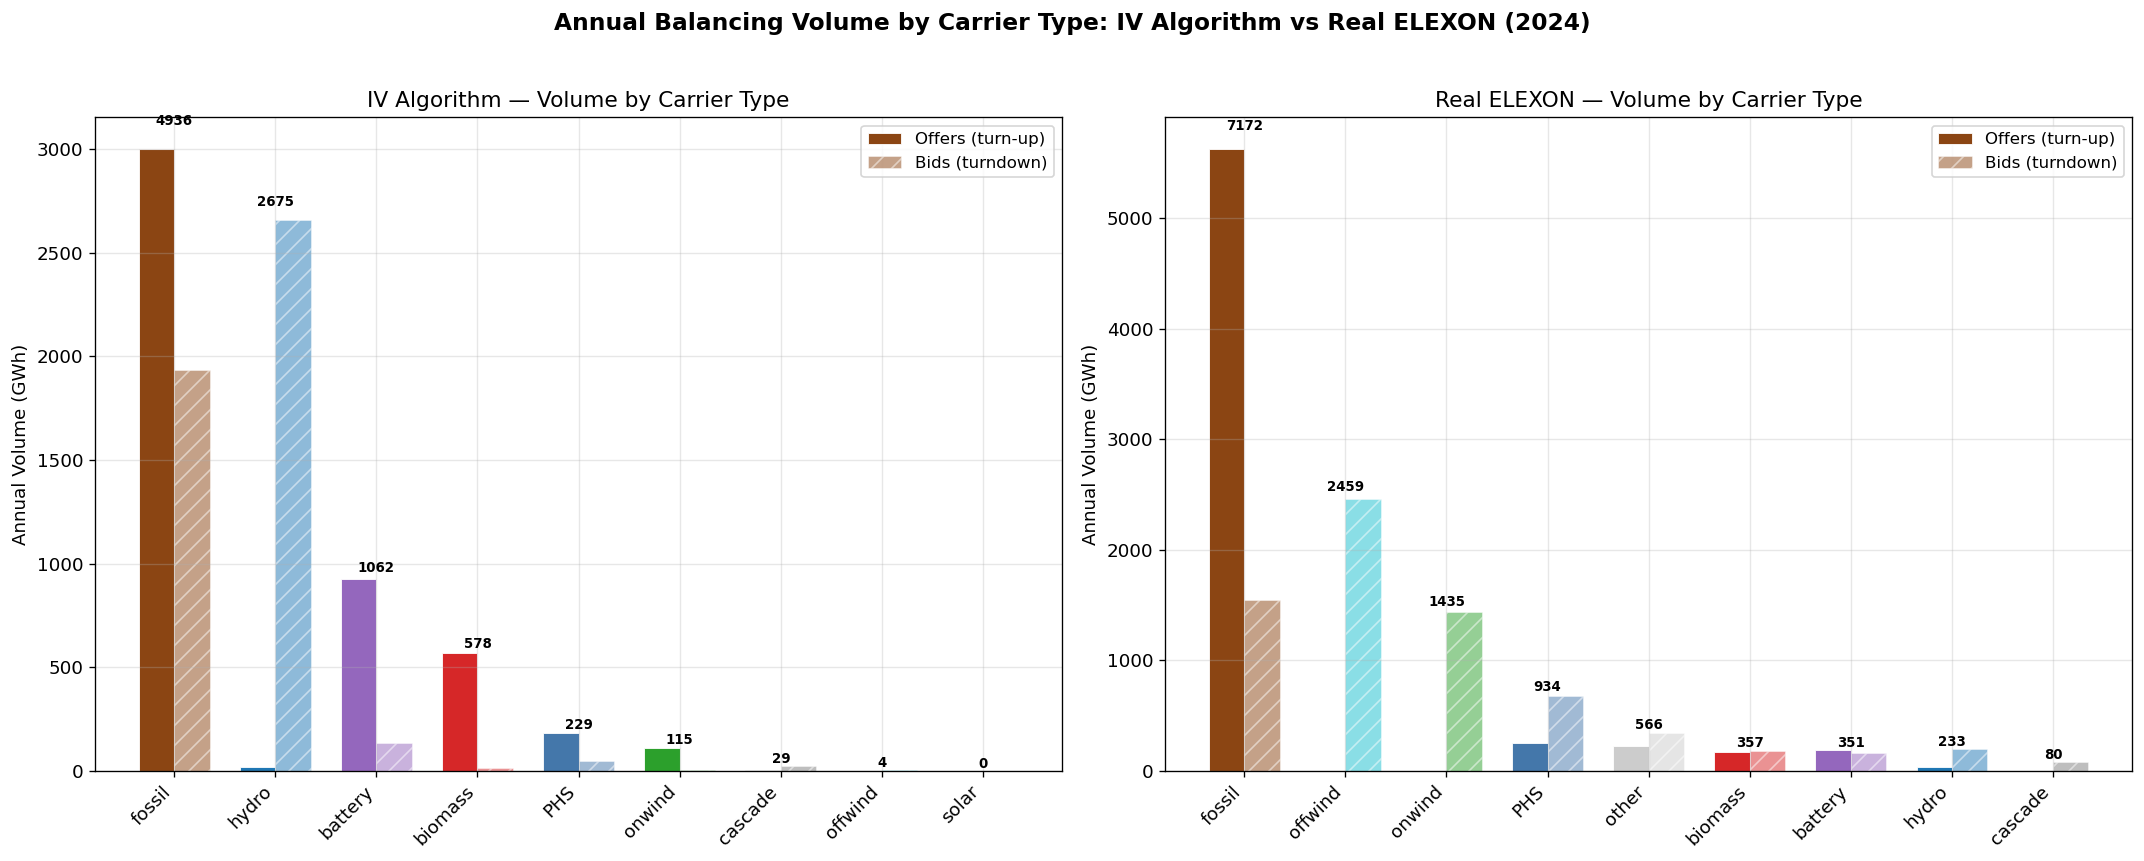


=== Volume by carrier (GWh) ===
              IV Offers  IV Bids  IV Total  Real Offers  Real Bids  Real Total
carrier_type                                                                  
PHS               182.3     46.5     228.8        255.2      678.6       933.8
battery           926.4    135.4    1061.8        185.6      165.2       350.7
biomass           566.4     11.7     578.1        173.4      183.4       356.8
cascade             4.3     24.6      28.9          0.9       79.3        80.3
fossil           3003.5   1932.3    4935.8       5630.0     1542.4      7172.4
hydro              18.8   2656.2    2675.0         39.0      194.4       233.4
offwind             1.0      2.9       3.9          0.7     2457.9      2458.7
onwind            111.1      4.2     115.3          0.1     1434.6      1434.7
other               0.0      0.0       0.0        222.0      343.9       566.0
solar               0.0      0.0       0.0          0.0        0.0         0.0


In [51]:
# --- Aggregate by carrier and action type ---
iv_by_carrier = iv_actions.groupby(['carrier_type', 'action_type'])['volume_mwh_actual'].sum().unstack(fill_value=0)
iv_by_carrier['total'] = iv_by_carrier.sum(axis=1)
iv_by_carrier = iv_by_carrier.sort_values('total', ascending=False)

real_by_carrier = real_actions.groupby(['carrier_type', 'action_type'])['volume_mwh'].sum().unstack(fill_value=0)
real_by_carrier['total'] = real_by_carrier.sum(axis=1)
real_by_carrier = real_by_carrier.sort_values('total', ascending=False)

# Align carrier order — union of both, sorted by max total
all_carriers = list(dict.fromkeys(
    list(iv_by_carrier.index) + list(real_by_carrier.index)
))

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

for ax, data, title, vol_col in [
    (axes[0], iv_by_carrier, 'IV Algorithm', 'volume_mwh_actual'),
    (axes[1], real_by_carrier, 'Real ELEXON', 'volume_mwh'),
]:
    carriers = data.index.tolist()
    x = np.arange(len(carriers))
    width = 0.35
    
    offer_vals = data.get('offer', pd.Series(0, index=carriers)).reindex(carriers, fill_value=0) / 1e3
    bid_vals = data.get('bid', pd.Series(0, index=carriers)).reindex(carriers, fill_value=0) / 1e3
    
    colors_offer = [CARRIER_COLORS.get(c, '#CCCCCC') for c in carriers]
    colors_bid = [CARRIER_COLORS.get(c, '#CCCCCC') for c in carriers]
    
    bars1 = ax.bar(x - width/2, offer_vals, width, label='Offers (turn-up)',
                   color=colors_offer, edgecolor='white', linewidth=0.5)
    bars2 = ax.bar(x + width/2, bid_vals, width, label='Bids (turndown)',
                   color=colors_bid, alpha=0.5, edgecolor='white', linewidth=0.5,
                   hatch='//')
    
    ax.set_xticks(x)
    ax.set_xticklabels(carriers, rotation=45, ha='right')
    ax.set_ylabel('Annual Volume (GWh)')
    ax.set_title(f'{title} — Volume by Carrier Type')
    ax.legend(loc='upper right')
    
    # Add total labels
    for i, c in enumerate(carriers):
        total = offer_vals.iloc[i] + bid_vals.iloc[i]
        ax.text(i, max(offer_vals.iloc[i], bid_vals.iloc[i]) + total*0.02,
                f'{total:.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

fig.suptitle('Annual Balancing Volume by Carrier Type: IV Algorithm vs Real ELEXON (2024)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_carrier_volume_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("\n=== Volume by carrier (GWh) ===")
summary = pd.DataFrame({
    'IV Offers': iv_by_carrier.get('offer', 0) / 1e3,
    'IV Bids': iv_by_carrier.get('bid', 0) / 1e3,
    'IV Total': iv_by_carrier['total'] / 1e3,
}).round(1)
summary_real = pd.DataFrame({
    'Real Offers': real_by_carrier.get('offer', 0) / 1e3,
    'Real Bids': real_by_carrier.get('bid', 0) / 1e3,
    'Real Total': real_by_carrier['total'] / 1e3,
}).round(1)
combined = summary.join(summary_real, how='outer').fillna(0)
print(combined.to_string())

### Plot 3a (cont.): Relative Share Comparison

Normalised view — what **percentage** of total balancing volume does each carrier account for? This removes the volume-level difference and directly compares portfolio composition.

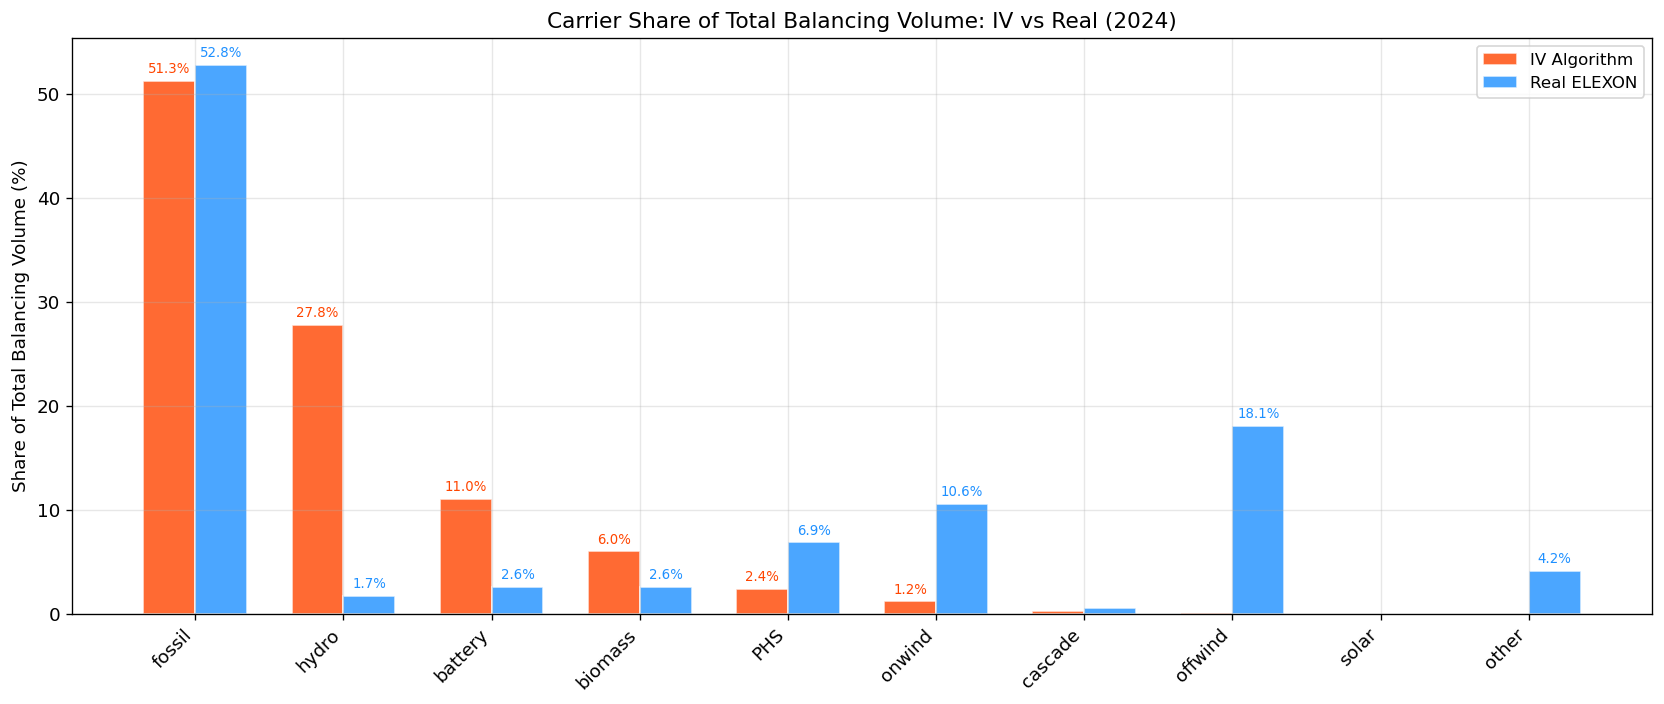

In [52]:
# Compute percentage shares
iv_share = (iv_by_carrier['total'] / iv_by_carrier['total'].sum() * 100).sort_values(ascending=False)
real_share = (real_by_carrier['total'] / real_by_carrier['total'].sum() * 100).sort_values(ascending=False)

# Align on same carrier set
all_carriers_share = list(dict.fromkeys(list(iv_share.index) + list(real_share.index)))
iv_share = iv_share.reindex(all_carriers_share, fill_value=0)
real_share = real_share.reindex(all_carriers_share, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(all_carriers_share))
width = 0.35

ax.bar(x - width/2, iv_share, width, label='IV Algorithm',
       color='orangered', alpha=0.8, edgecolor='white')
ax.bar(x + width/2, real_share, width, label='Real ELEXON',
       color='dodgerblue', alpha=0.8, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(all_carriers_share, rotation=45, ha='right')
ax.set_ylabel('Share of Total Balancing Volume (%)')
ax.set_title('Carrier Share of Total Balancing Volume: IV vs Real (2024)')
ax.legend()

# Add percentage labels
for i, c in enumerate(all_carriers_share):
    if iv_share.iloc[i] > 1:
        ax.text(i - width/2, iv_share.iloc[i] + 0.5, f'{iv_share.iloc[i]:.1f}%',
                ha='center', va='bottom', fontsize=8, color='orangered')
    if real_share.iloc[i] > 1:
        ax.text(i + width/2, real_share.iloc[i] + 0.5, f'{real_share.iloc[i]:.1f}%',
                ha='center', va='bottom', fontsize=8, color='dodgerblue')

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_carrier_share_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Plot 3b: Acceptance Rate by Zone × Carrier (IV Model)

**What fraction of submitted volume is actually accepted** by the IV clearing algorithm, broken down by carrier type and zone? This reveals which technologies are supply-constrained vs demand-limited — e.g., a high acceptance rate for wind in northern zones means most submitted wind curtailment is needed to manage congestion.

We compare submitted bids/offers against cleared actions per zone-carrier combination.

Loading submitted bids/offers: 100%|██████████| 366/366 [02:06<00:00,  2.90it/s]


Loaded submitted data for 366 days


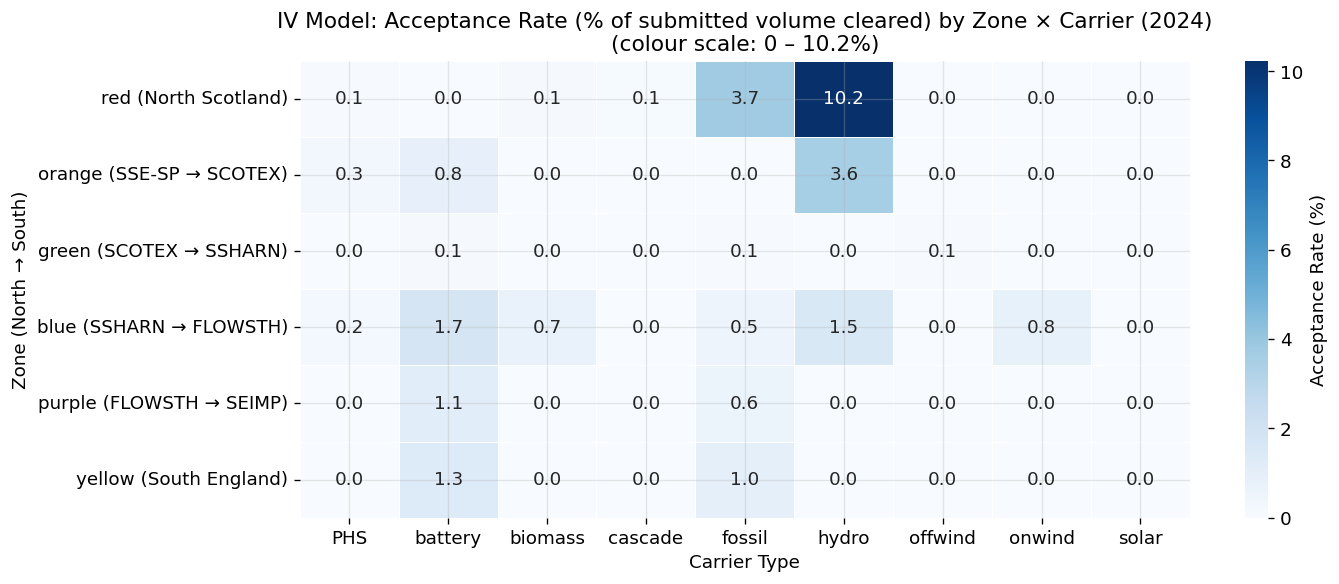


Acceptance rate summary:
carrier_type  PHS  battery  biomass  cascade  fossil  hydro  offwind  onwind  solar
zone                                                                               
red           0.1      0.0      0.1      0.1     3.7   10.2      0.0     0.0    0.0
orange        0.3      0.8      0.0      0.0     0.0    3.6      0.0     0.0    0.0
green         0.0      0.1      0.0      0.0     0.1    0.0      0.1     0.0    0.0
blue          0.2      1.7      0.7      0.0     0.5    1.5      0.0     0.8    0.0
purple        0.0      1.1      0.0      0.0     0.6    0.0      0.0     0.0    0.0
yellow        0.0      1.3      0.0      0.0     1.0    0.0      0.0     0.0    0.0


In [53]:

# Load submitted bids and offers across all days
submitted_list = []
missing_sub = 0

for day_str in tqdm(all_dates, desc="Loading submitted bids/offers"):
    for file_type, price_col in [('submitted_bids', 'Bid'), ('submitted_offers', 'Offer')]:
        fpath = DATA_DIR / day_str / f'{file_type}.csv'
        if not fpath.exists():
            if file_type == 'submitted_offers':
                missing_sub += 1
            continue
        
        df = pd.read_csv(fpath)
        # Volume is abs(LevelFrom) in MW per SP
        df['vol_mwh'] = df['LevelFrom'].abs() * 0.5
        
        # Map to carrier and zone
        df['carrier_type'] = df['NationalGridBmUnit'].map(
            bmu_class['carrier'].to_dict()
        ).fillna('other')
        df['zone'] = df['NationalGridBmUnit'].map(
            bmu_class['zone'].to_dict()
        ).fillna('unknown')
        
        action = 'bid' if file_type == 'submitted_bids' else 'offer'
        
        agg = df.groupby(['carrier_type', 'zone']).agg(
            submitted_vol=('vol_mwh', 'sum'),
            n_submissions=('vol_mwh', 'count'),
        ).reset_index()
        agg['action_type'] = action
        agg['date'] = day_str
        submitted_list.append(agg)

submitted_all = pd.concat(submitted_list, ignore_index=True)
submitted_all['date'] = pd.to_datetime(submitted_all['date'])

print(f"Loaded submitted data for {len(all_dates) - missing_sub} days")

# Aggregate submitted volume by carrier × zone
sub_agg = submitted_all.groupby(['carrier_type', 'zone'])['submitted_vol'].sum().reset_index()

# Aggregate accepted IV volume by carrier × zone
iv_agg = iv_actions.groupby(['carrier_type', 'zone'])['volume_mwh_actual'].sum().reset_index()
iv_agg.columns = ['carrier_type', 'zone', 'accepted_vol']

# Merge and compute acceptance rate
accept_df = sub_agg.merge(iv_agg, on=['carrier_type', 'zone'], how='left')
accept_df['accepted_vol'] = accept_df['accepted_vol'].fillna(0)
accept_df['acceptance_rate'] = (accept_df['accepted_vol'] / accept_df['submitted_vol'] * 100).clip(0, 100)

# Pivot for heatmap: zones as rows, carriers as columns
pivot = accept_df.pivot_table(
    index='zone', columns='carrier_type', values='acceptance_rate', fill_value=0
)

# Reorder zones north→south; keep only carriers with >0 submissions
zone_order_present = [z for z in ZONE_ORDER if z in pivot.index]
pivot = pivot.reindex(zone_order_present)
pivot = pivot.loc[:, pivot.sum() > 0]  # drop empty carriers

# Scale colormap to actual data range — all values are <15% so fix vmax explicitly
vmax_val = pivot.values.max()

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'Acceptance Rate (%)'}, ax=ax,
            vmin=0, vmax=vmax_val)
ax.set_yticklabels([f"{z} ({ZONE_NAMES.get(z, z)})" for z in zone_order_present], rotation=0)
ax.set_xlabel('Carrier Type')
ax.set_ylabel('Zone (North → South)')
ax.set_title(f'IV Model: Acceptance Rate (% of submitted volume cleared) by Zone × Carrier (2024)\n'
             f'(colour scale: 0 – {vmax_val:.1f}%)')

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_acceptance_rate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAcceptance rate summary:")
print(pivot.round(1).to_string())


---
## Plot 3c: Top 20 Individual BMUs by Total Accepted Volume & Cost (IV Model)

Which individual generators/batteries carry the heaviest balancing load in the IV model? These are the "indispensable" units — if a single plant dominates, the results are sensitive to its availability and pricing.

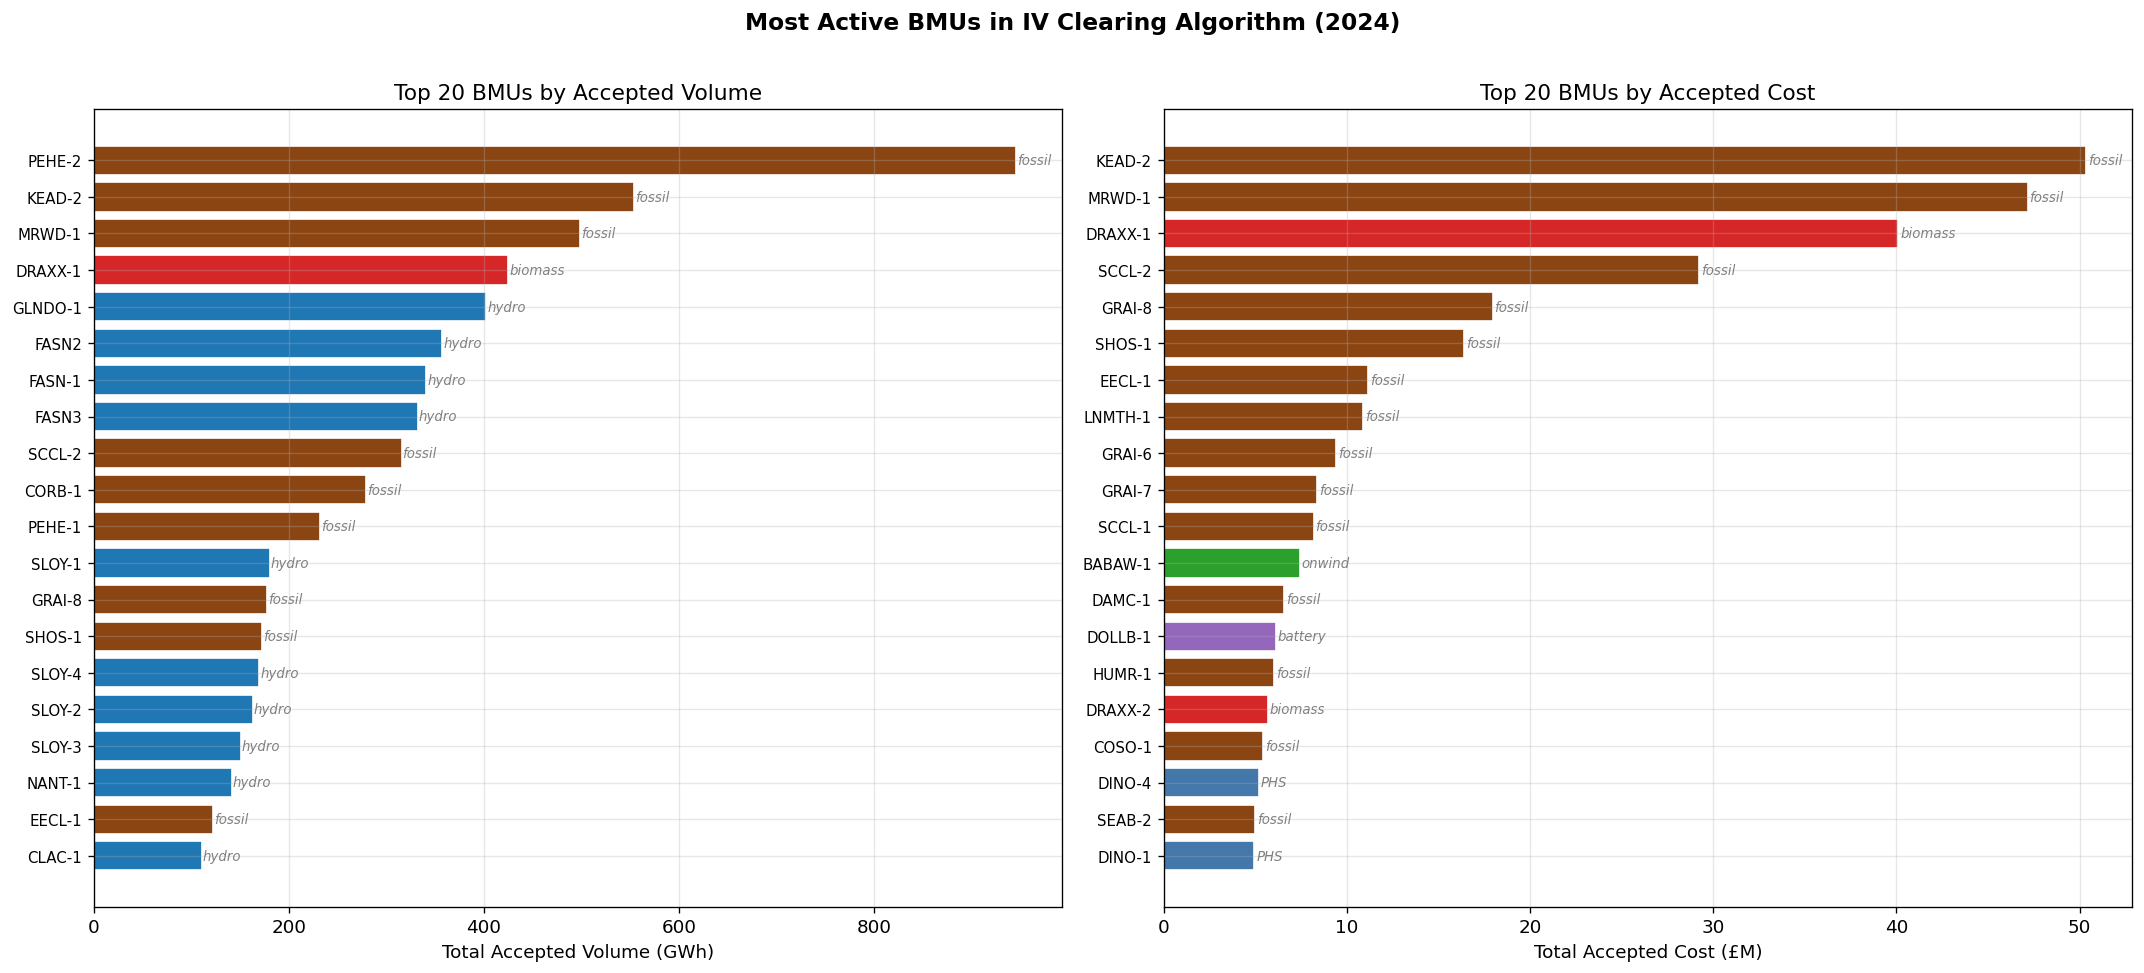


Top 20 BMUs by volume:
unit_id carrier_type total_vol_mwh total_cost_gbp  n_days cost_per_mwh
 PEHE-2       fossil     945.9 GWh       £-37.84M     171   £-40.0/MWh
 KEAD-2       fossil     554.3 GWh        £50.36M     186    £90.9/MWh
 MRWD-1       fossil     498.6 GWh        £47.16M     251    £94.6/MWh
DRAXX-1      biomass     424.9 GWh        £40.11M     120    £94.4/MWh
GLNDO-1        hydro     402.3 GWh       £-21.93M     216   £-54.5/MWh
  FASN2        hydro     357.2 GWh       £-19.41M     226   £-54.3/MWh
 FASN-1        hydro     341.2 GWh       £-18.55M     210   £-54.4/MWh
  FASN3        hydro     332.2 GWh       £-18.31M     200   £-55.1/MWh
 SCCL-2       fossil     315.6 GWh        £29.22M     138    £92.6/MWh
 CORB-1       fossil     279.7 GWh       £-43.98M     105  £-157.2/MWh
 PEHE-1       fossil     231.7 GWh        £-9.55M     109   £-41.2/MWh
 SLOY-1        hydro     180.6 GWh        £-7.35M     185   £-40.7/MWh
 GRAI-8       fossil     177.3 GWh        £17.96M    

In [54]:
# Aggregate by unit
top_units = iv_actions.groupby(['unit_id', 'carrier_type']).agg(
    total_vol_mwh=('volume_mwh_actual', 'sum'),
    total_cost_gbp=('cost_gbp', 'sum'),
    n_actions=('volume_mwh_actual', 'count'),
    n_days=('date', 'nunique'),
    mean_price=('price_per_mwh', 'mean'),
).reset_index()

top_units['cost_per_mwh'] = top_units['total_cost_gbp'] / top_units['total_vol_mwh'].replace(0, np.nan)

# Top 20 by volume
top20_vol = top_units.nlargest(20, 'total_vol_mwh')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Panel 1: Top 20 by volume
ax = axes[0]
colors = [CARRIER_COLORS.get(c, '#CCCCCC') for c in top20_vol['carrier_type']]
y_pos = np.arange(len(top20_vol))
ax.barh(y_pos, top20_vol['total_vol_mwh'] / 1e3, color=colors, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(top20_vol['unit_id'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Total Accepted Volume (GWh)')
ax.set_title('Top 20 BMUs by Accepted Volume')

# Add carrier labels
for i, (_, row) in enumerate(top20_vol.iterrows()):
    ax.text(row['total_vol_mwh']/1e3 + 1, i, row['carrier_type'],
            va='center', fontsize=8, style='italic', color='grey')

# Panel 2: Top 20 by cost
top20_cost = top_units.nlargest(20, 'total_cost_gbp')
ax = axes[1]
colors = [CARRIER_COLORS.get(c, '#CCCCCC') for c in top20_cost['carrier_type']]
y_pos = np.arange(len(top20_cost))
ax.barh(y_pos, top20_cost['total_cost_gbp'] / 1e6, color=colors, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(top20_cost['unit_id'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Total Accepted Cost (£M)')
ax.set_title('Top 20 BMUs by Accepted Cost')

for i, (_, row) in enumerate(top20_cost.iterrows()):
    ax.text(row['total_cost_gbp']/1e6 + 0.1, i, row['carrier_type'],
            va='center', fontsize=8, style='italic', color='grey')

fig.suptitle('Most Active BMUs in IV Clearing Algorithm (2024)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_top20_bmus.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\nTop 20 BMUs by volume:")
display_cols = ['unit_id', 'carrier_type', 'total_vol_mwh', 'total_cost_gbp', 'n_days', 'cost_per_mwh']
top20_display = top20_vol[display_cols].copy()
top20_display['total_vol_mwh'] = top20_display['total_vol_mwh'].map(lambda x: f"{x/1e3:.1f} GWh")
top20_display['total_cost_gbp'] = top20_display['total_cost_gbp'].map(lambda x: f"£{x/1e6:.2f}M")
top20_display['cost_per_mwh'] = top20_display['cost_per_mwh'].map(lambda x: f"£{x:.1f}/MWh")
print(top20_display.to_string(index=False))

---
## Plot 3c-bis: Top 20 BMUs by Accepted Volume — IV vs Real ELEXON (Side by Side)

A direct comparison of the most-called individual units. Are the same BMUs dominating in both the IV algorithm and the real SO dispatch? If different units appear, it reveals structural differences in how the model selects balancing resources compared to the real operator.

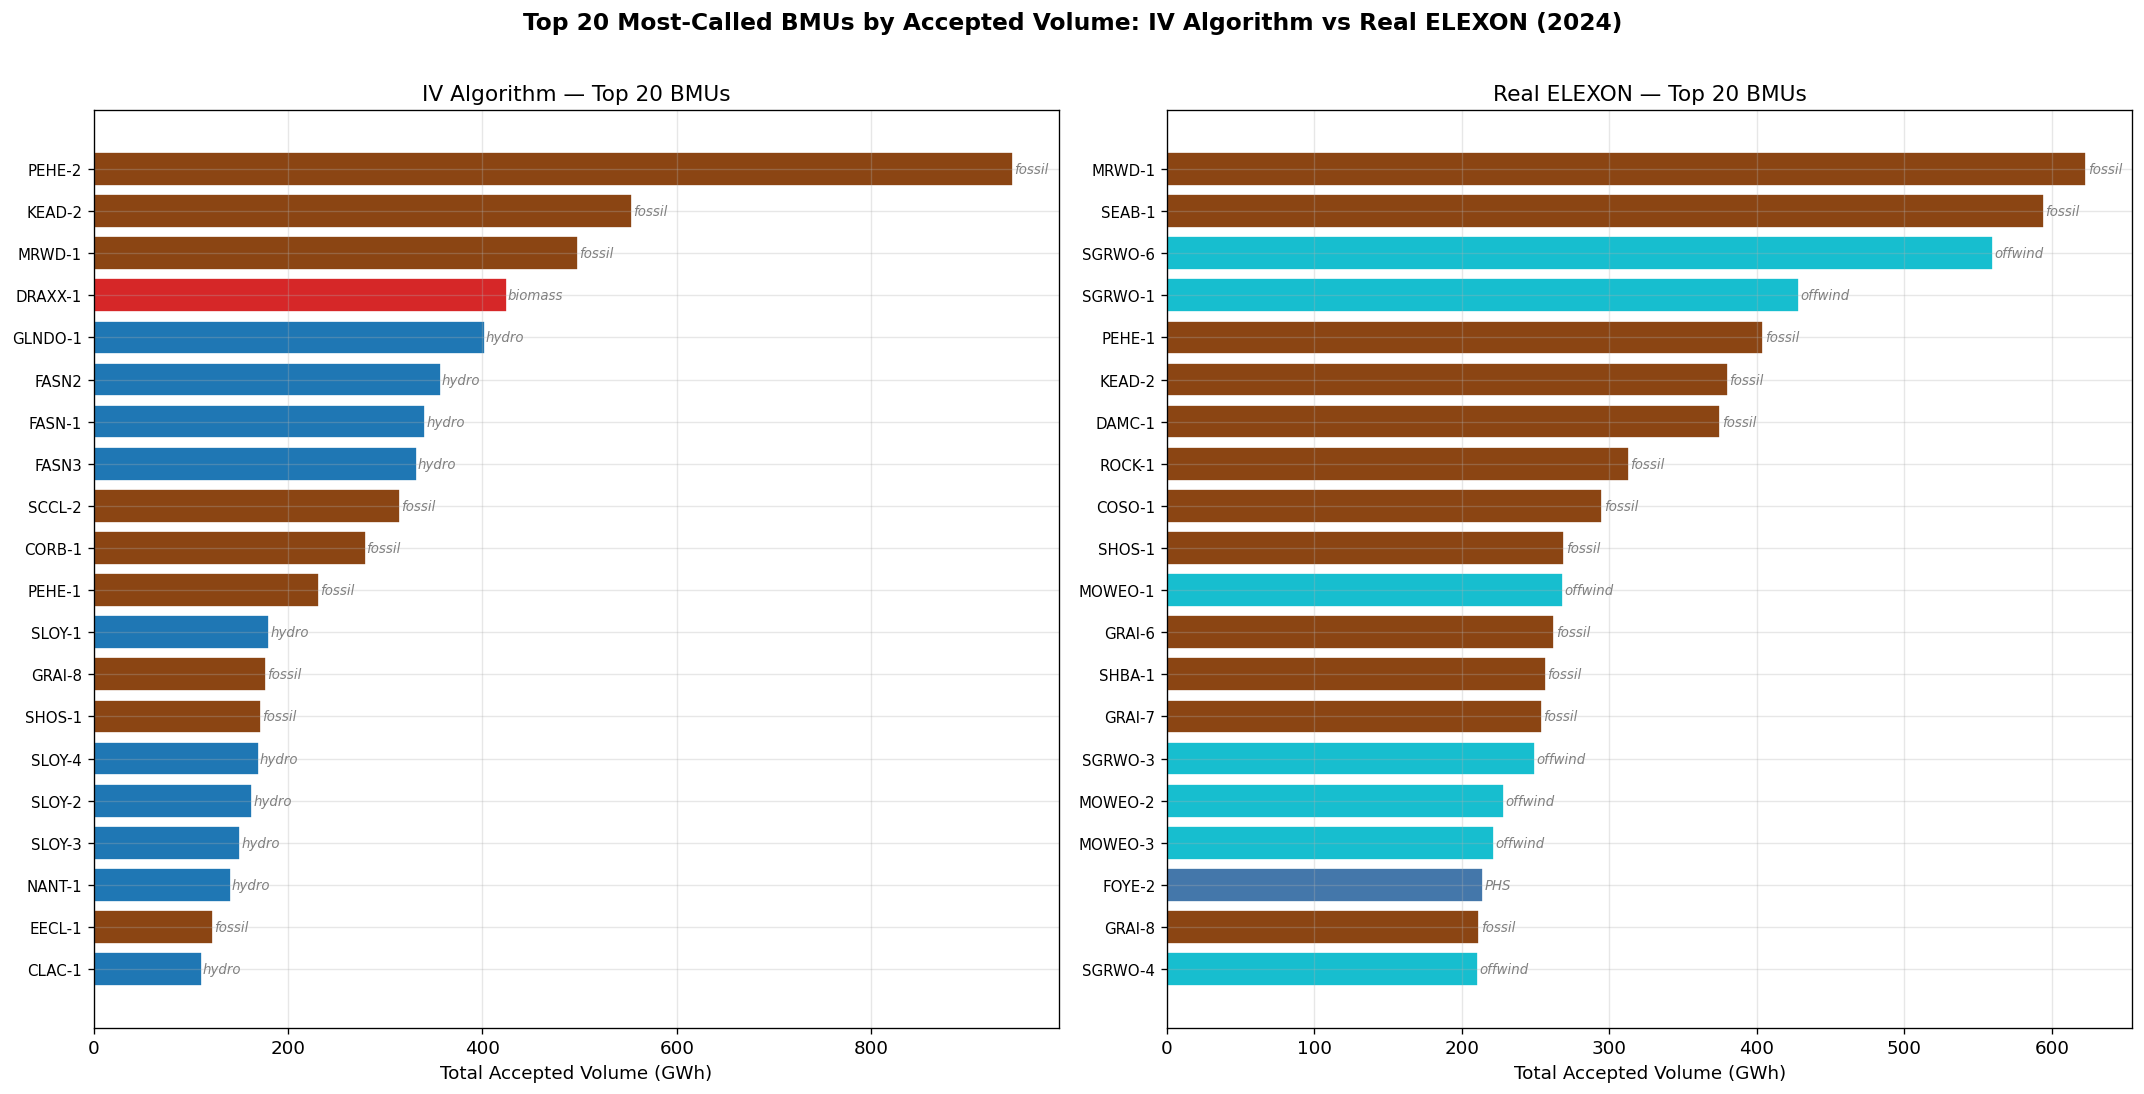


=== Top 20 BMU Overlap Analysis ===
BMUs in BOTH top-20 lists: 5 — ['GRAI-8', 'KEAD-2', 'MRWD-1', 'PEHE-1', 'SHOS-1']
Only in IV top-20:         15 — ['CLAC-1', 'CORB-1', 'DRAXX-1', 'EECL-1', 'FASN-1', 'FASN2', 'FASN3', 'GLNDO-1', 'NANT-1', 'PEHE-2', 'SCCL-2', 'SLOY-1', 'SLOY-2', 'SLOY-3', 'SLOY-4']
Only in Real top-20:       15 — ['COSO-1', 'DAMC-1', 'FOYE-2', 'GRAI-6', 'GRAI-7', 'MOWEO-1', 'MOWEO-2', 'MOWEO-3', 'ROCK-1', 'SEAB-1', 'SGRWO-1', 'SGRWO-3', 'SGRWO-4', 'SGRWO-6', 'SHBA-1']

--- IV Top 20 ---
unit_id carrier_type   GWh
 PEHE-2       fossil 945.9
 KEAD-2       fossil 554.3
 MRWD-1       fossil 498.6
DRAXX-1      biomass 424.9
GLNDO-1        hydro 402.3
  FASN2        hydro 357.2
 FASN-1        hydro 341.2
  FASN3        hydro 332.2
 SCCL-2       fossil 315.6
 CORB-1       fossil 279.7
 PEHE-1       fossil 231.7
 SLOY-1        hydro 180.6
 GRAI-8       fossil 177.3
 SHOS-1       fossil 172.4
 SLOY-4        hydro 169.8
 SLOY-2        hydro 163.4
 SLOY-3        hydro 151.1
 NA

In [61]:
# ---- Top 20 BMUs by accepted volume: IV vs Real (side by side) ----

# IV: already computed in top_units
top20_iv = top_units.nlargest(20, 'total_vol_mwh').copy()
top20_iv = top20_iv[['unit_id', 'carrier_type', 'total_vol_mwh']].reset_index(drop=True)

# Real: aggregate by BMU
real_top_units = real_actions.groupby(['bmu', 'carrier_type']).agg(
    total_vol_mwh=('volume_mwh', 'sum'),
).reset_index()
# If a BMU appears with multiple carrier_types (unlikely but possible), sum first
real_top_units = real_top_units.groupby('bmu').agg(
    total_vol_mwh=('total_vol_mwh', 'sum'),
    carrier_type=('carrier_type', 'first'),
).reset_index()
top20_real = real_top_units.nlargest(20, 'total_vol_mwh').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# ---- Panel 1: IV Top 20 ----
ax = axes[0]
colors_iv = [CARRIER_COLORS.get(c, '#CCCCCC') for c in top20_iv['carrier_type']]
y_pos = np.arange(len(top20_iv))
ax.barh(y_pos, top20_iv['total_vol_mwh'] / 1e3, color=colors_iv, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(top20_iv['unit_id'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Total Accepted Volume (GWh)')
ax.set_title('IV Algorithm — Top 20 BMUs')

for i, row in top20_iv.iterrows():
    ax.text(row['total_vol_mwh']/1e3 + 1, i, f"{row['carrier_type']}",
            va='center', fontsize=8, style='italic', color='grey')

# ---- Panel 2: Real Top 20 ----
ax = axes[1]
colors_real = [CARRIER_COLORS.get(c, '#CCCCCC') for c in top20_real['carrier_type']]
y_pos = np.arange(len(top20_real))
ax.barh(y_pos, top20_real['total_vol_mwh'] / 1e3, color=colors_real, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(top20_real['bmu'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Total Accepted Volume (GWh)')
ax.set_title('Real ELEXON — Top 20 BMUs')

for i, row in top20_real.iterrows():
    ax.text(row['total_vol_mwh']/1e3 + 1, i, f"{row['carrier_type']}",
            va='center', fontsize=8, style='italic', color='grey')

fig.suptitle('Top 20 Most-Called BMUs by Accepted Volume: IV Algorithm vs Real ELEXON (2024)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_top20_bmus_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Overlap analysis ----
iv_set = set(top20_iv['unit_id'])
real_set = set(top20_real['bmu'])
overlap = iv_set & real_set
only_iv = iv_set - real_set
only_real = real_set - iv_set

print(f"\n=== Top 20 BMU Overlap Analysis ===")
print(f"BMUs in BOTH top-20 lists: {len(overlap)} — {sorted(overlap) if overlap else 'None'}")
print(f"Only in IV top-20:         {len(only_iv)} — {sorted(only_iv)}")
print(f"Only in Real top-20:       {len(only_real)} — {sorted(only_real)}")

# Summary table
print("\n--- IV Top 20 ---")
iv_display = top20_iv.copy()
iv_display['GWh'] = (iv_display['total_vol_mwh'] / 1e3).round(1)
print(iv_display[['unit_id', 'carrier_type', 'GWh']].to_string(index=False))

print("\n--- Real Top 20 ---")
real_display = top20_real.copy()
real_display['GWh'] = (real_display['total_vol_mwh'] / 1e3).round(1)
print(real_display[['bmu', 'carrier_type', 'GWh']].to_string(index=False))

---
## Plot 3d: Accepted Balancing Volume by Zone and Direction — IV MODEL ONLY

> **Note:** This chart shows the **IV model's accepted clearing actions** (from `IV_clearing_accepted_actions_flex.csv`), consistent with all other IV charts in this notebook. It does NOT use the dispatch-changes file, which tracks net physical output changes across all generators (including those not directly selected by the clearing algorithm).

Stacked bars showing which carriers' bids/offers were accepted by the IV clearing algorithm in each zone:
- **Offers (turn-up)**: accepted offers to increase output
- **Bids (turndown)**: accepted bids to reduce output

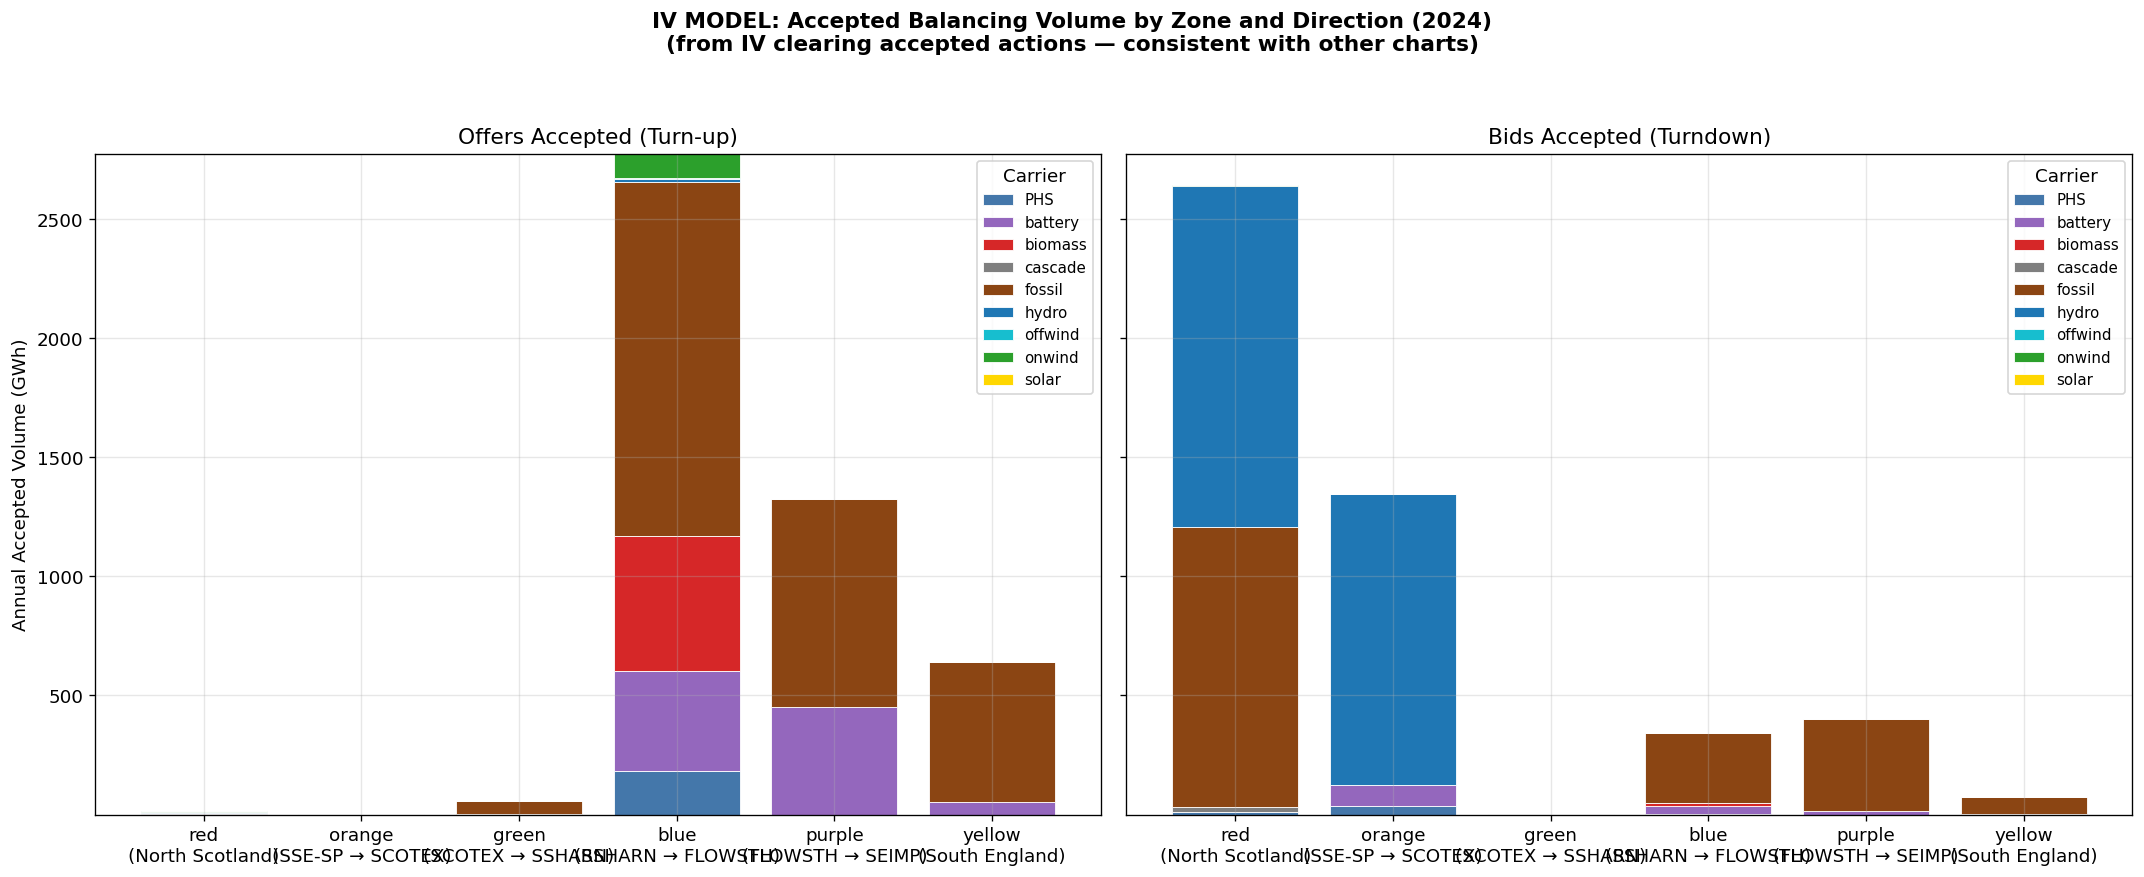


Offers accepted (turn-up) by zone (GWh):
carrier_type    PHS  battery  biomass  cascade  fossil  hydro  offwind  onwind  solar
zone                                                                                 
red             0.0      0.0      0.7      4.3     0.6    5.3      0.0     5.1    0.0
orange          0.0      0.3      0.0      0.0     0.0    0.8      0.0     1.9    0.0
green           0.0      2.5      0.0      0.0    52.5    0.0      0.0     0.0    0.0
blue          182.3    420.2    565.7      0.0  1489.4   12.7      1.0   104.1    0.0
purple          0.0    450.6      0.0      0.0   874.0    0.0      0.0     0.0    0.0
yellow          0.0     52.8      0.0      0.0   587.0    0.0      0.0     0.0    0.0

Bids accepted (turndown) by zone (GWh):
carrier_type   PHS  battery  biomass  cascade  fossil   hydro  offwind  onwind  solar
zone                                                                                 
red            8.7      0.0      0.0     21.6  1177.1  14

In [62]:
# ---- Use iv_actions (accepted clearing actions) for consistency with all other charts ----
# Previously this used IV_dispatch_changes_by_zone_and_type_flex.csv which tracks
# the NET physical dispatch change for ALL generators (wholesale vs redispatch),
# NOT just the units whose bids/offers were accepted by the clearing algorithm.
# That caused wind to appear dominant in flex-down even though the clearing algorithm
# rarely accepts wind bids — the wind output changed because of network-level redispatch.

# Aggregate accepted volume by zone × carrier × direction
iv_zone_dir = iv_actions.groupby(['zone', 'carrier_type', 'action_type'])['volume_mwh_actual'].sum().reset_index()

# Separate offers (up) and bids (down)
iv_up = iv_zone_dir[iv_zone_dir['action_type'] == 'offer'].copy()
iv_down = iv_zone_dir[iv_zone_dir['action_type'] == 'bid'].copy()

# Pivot for stacked bars
pivot_up = iv_up.pivot_table(index='zone', columns='carrier_type', values='volume_mwh_actual', fill_value=0)
pivot_down = iv_down.pivot_table(index='zone', columns='carrier_type', values='volume_mwh_actual', fill_value=0)

# Make down absolute for plotting (bids may already be positive volume)
pivot_down = pivot_down.abs()

# Reorder zones north→south
zones_present = [z for z in ZONE_ORDER + ['unknown'] if z in pivot_up.index or z in pivot_down.index]
pivot_up = pivot_up.reindex(zones_present, fill_value=0)
pivot_down = pivot_down.reindex(zones_present, fill_value=0)

# Get all carriers across both directions
all_types = sorted(set(list(pivot_up.columns) + list(pivot_down.columns)))
pivot_up = pivot_up.reindex(columns=all_types, fill_value=0)
pivot_down = pivot_down.reindex(columns=all_types, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Zone labels with names
zone_labels = [f"{z}\n({ZONE_NAMES.get(z, z)})" for z in zones_present]

# Plot offers (turn-up)
ax = axes[0]
bottom = np.zeros(len(zones_present))
for carrier in all_types:
    vals = pivot_up[carrier].values / 1e3  # GWh
    ax.bar(zone_labels, vals, bottom=bottom, label=carrier,
           color=CARRIER_COLORS.get(carrier, '#CCCCCC'), edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_ylabel('Annual Accepted Volume (GWh)')
ax.set_title('Offers Accepted (Turn-up)')
ax.legend(title='Carrier', loc='upper right', fontsize=9)

# Plot bids (turndown)
ax = axes[1]
bottom = np.zeros(len(zones_present))
for carrier in all_types:
    vals = pivot_down[carrier].values / 1e3  # GWh
    ax.bar(zone_labels, vals, bottom=bottom, label=carrier,
           color=CARRIER_COLORS.get(carrier, '#CCCCCC'), edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_title('Bids Accepted (Turndown)')
ax.legend(title='Carrier', loc='upper right', fontsize=9)

fig.suptitle('IV MODEL: Accepted Balancing Volume by Zone and Direction (2024)\n'
             '(from IV clearing accepted actions — consistent with other charts)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_zone_tech_composition.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nOffers accepted (turn-up) by zone (GWh):")
print((pivot_up / 1e3).round(1).to_string())
print("\nBids accepted (turndown) by zone (GWh):")
print((pivot_down / 1e3).round(1).to_string())

---
## Plot 3e: Monthly Technology Mix Evolution

How does the carrier mix change across seasons? Wind curtailment should peak in winter (high wind), battery usage may peak in summer (solar patterns), and gas usage may track demand peaks.

Stacked area chart showing monthly contribution of each carrier to total IV balancing volume.

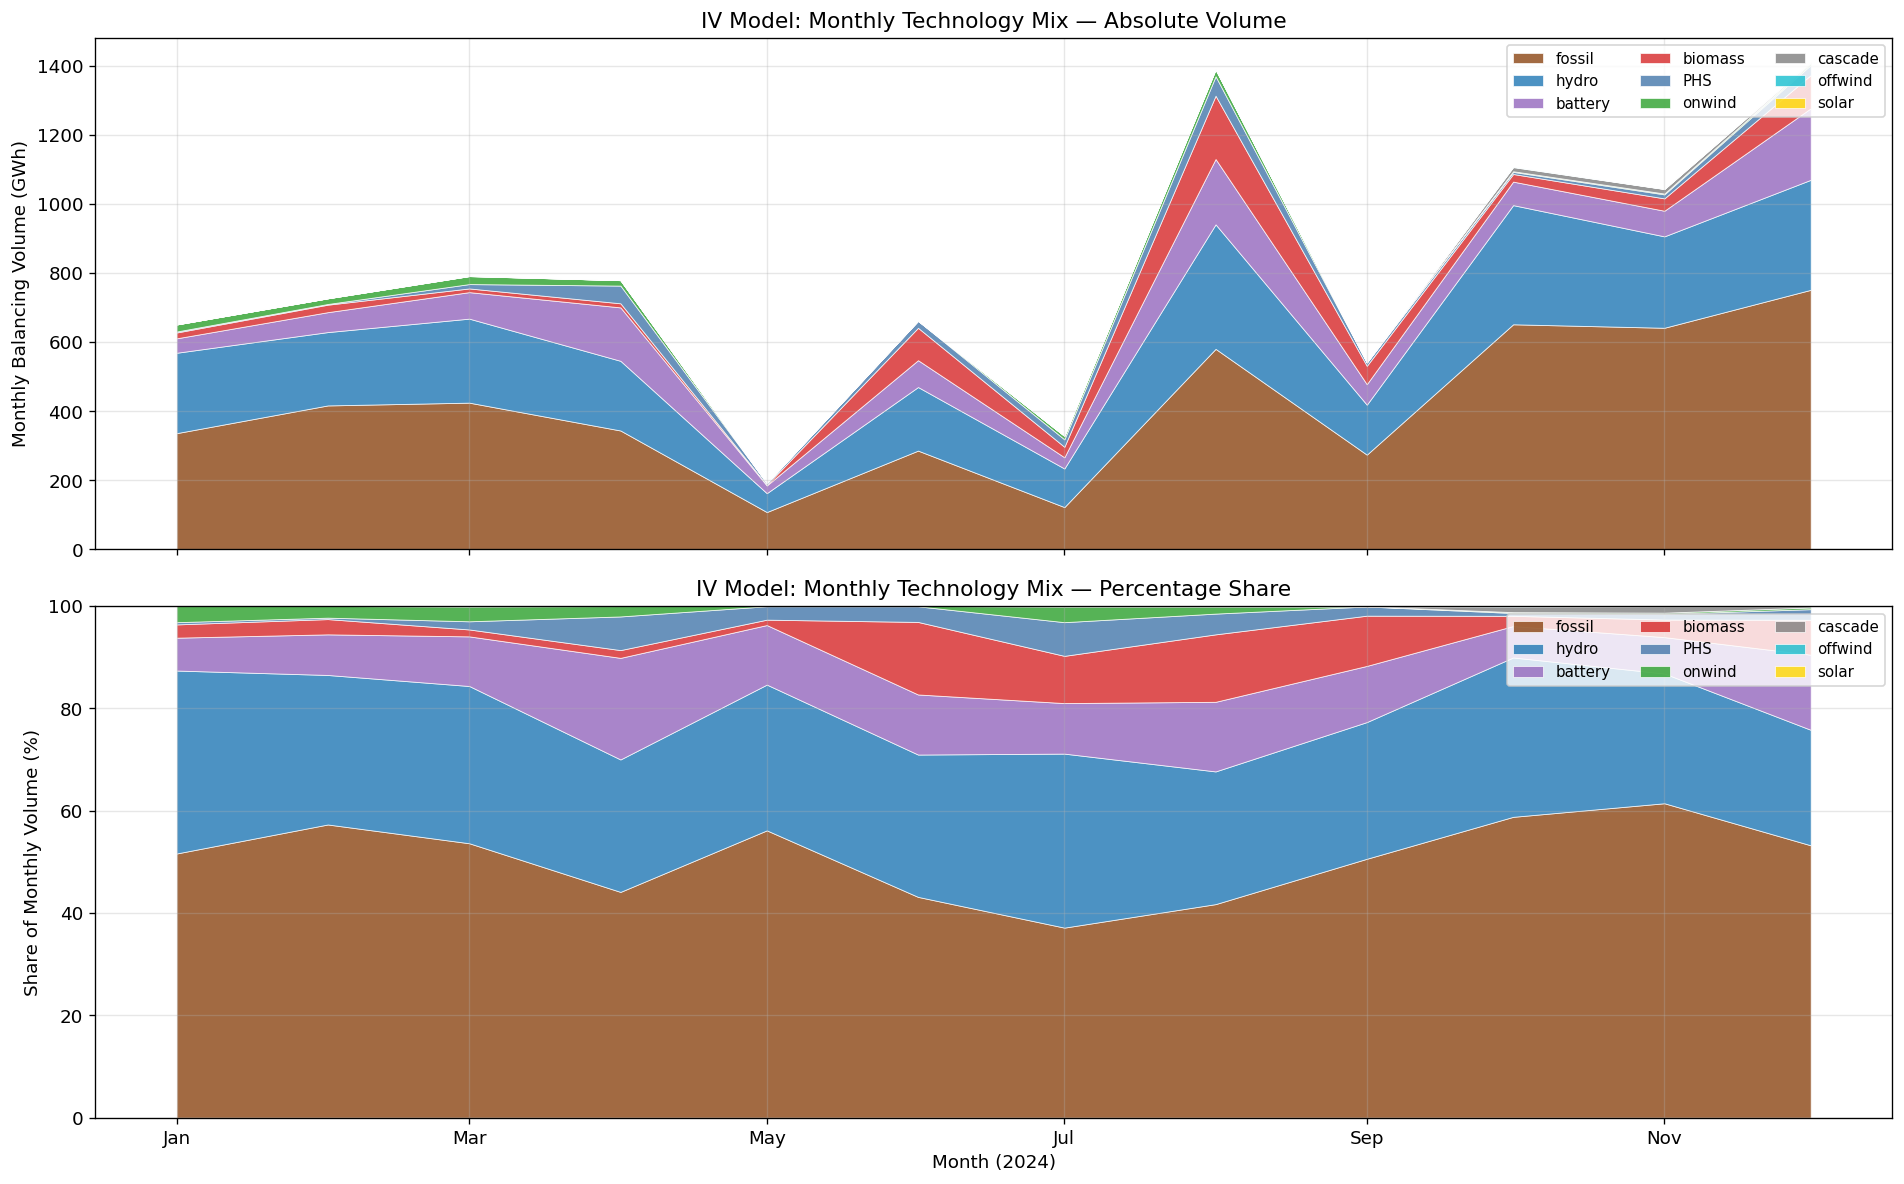

Monthly volume by carrier (GWh):
carrier_type  fossil  hydro  battery  biomass   PHS  onwind  cascade  offwind  solar
month                                                                               
2024-01        336.2  232.9     41.8     16.9   2.8    20.5      0.0      0.0    0.0
2024-02        416.6  212.4     57.7     21.7   2.0    16.5      0.0      0.0    0.0
2024-03        424.6  243.3     76.8     10.7  12.6    23.1      0.1      0.4    0.0
2024-04        344.0  201.8    154.8     11.8  51.3    15.7      0.1      0.0    0.0
2024-05        107.7   54.7     22.3      2.0   5.0     0.1      0.0      0.0    0.0
2024-06        285.7  184.2     77.7     93.9  20.2     0.3      0.0      0.0    0.0
2024-07        122.1  111.8     32.5     30.3  21.6    10.2      0.0      0.2    0.0
2024-08        580.4  360.7    189.2    183.4  56.4    19.7      0.0      0.9    0.0
2024-09        274.0  144.7     59.5     53.2   9.7     0.1      0.0      0.4    0.0
2024-10        651.6  345.2     

In [56]:
# Monthly carrier breakdown for IV model
iv_monthly = iv_actions.groupby(['month', 'carrier_type'])['volume_mwh_actual'].sum().unstack(fill_value=0)
iv_monthly = iv_monthly / 1e3  # GWh

# Sort carriers by total contribution (largest on bottom of stack)
carrier_order = iv_monthly.sum().sort_values(ascending=False).index.tolist()
iv_monthly = iv_monthly[carrier_order]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Panel 1: Stacked area (absolute GWh)
ax = axes[0]
month_dates = [p.to_timestamp() for p in iv_monthly.index]
colors = [CARRIER_COLORS.get(c, '#CCCCCC') for c in carrier_order]

ax.stackplot(month_dates, [iv_monthly[c].values for c in carrier_order],
             labels=carrier_order, colors=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Monthly Balancing Volume (GWh)')
ax.set_title('IV Model: Monthly Technology Mix — Absolute Volume')
ax.legend(loc='upper right', ncol=3, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Panel 2: Normalised (% share)
ax = axes[1]
iv_monthly_pct = iv_monthly.div(iv_monthly.sum(axis=1), axis=0) * 100

ax.stackplot(month_dates, [iv_monthly_pct[c].values for c in carrier_order],
             labels=carrier_order, colors=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Share of Monthly Volume (%)')
ax.set_xlabel('Month (2024)')
ax.set_title('IV Model: Monthly Technology Mix — Percentage Share')
ax.set_ylim(0, 100)
ax.legend(loc='upper right', ncol=3, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_monthly_tech_mix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Monthly volume by carrier (GWh):")
print(iv_monthly.round(1).to_string())

---
## Plot 3f: Price Distribution by Carrier Type (IV Accepted Actions)

Box plots showing the distribution of accepted prices for each carrier type, split by direction. This reveals **why** the merit-order algorithm selects certain technologies:
- Cheap carriers with low offer prices get selected first for turn-up
- Carriers with high bid prices get selected first for turndown
- The spread shows how consistently competitive each technology is

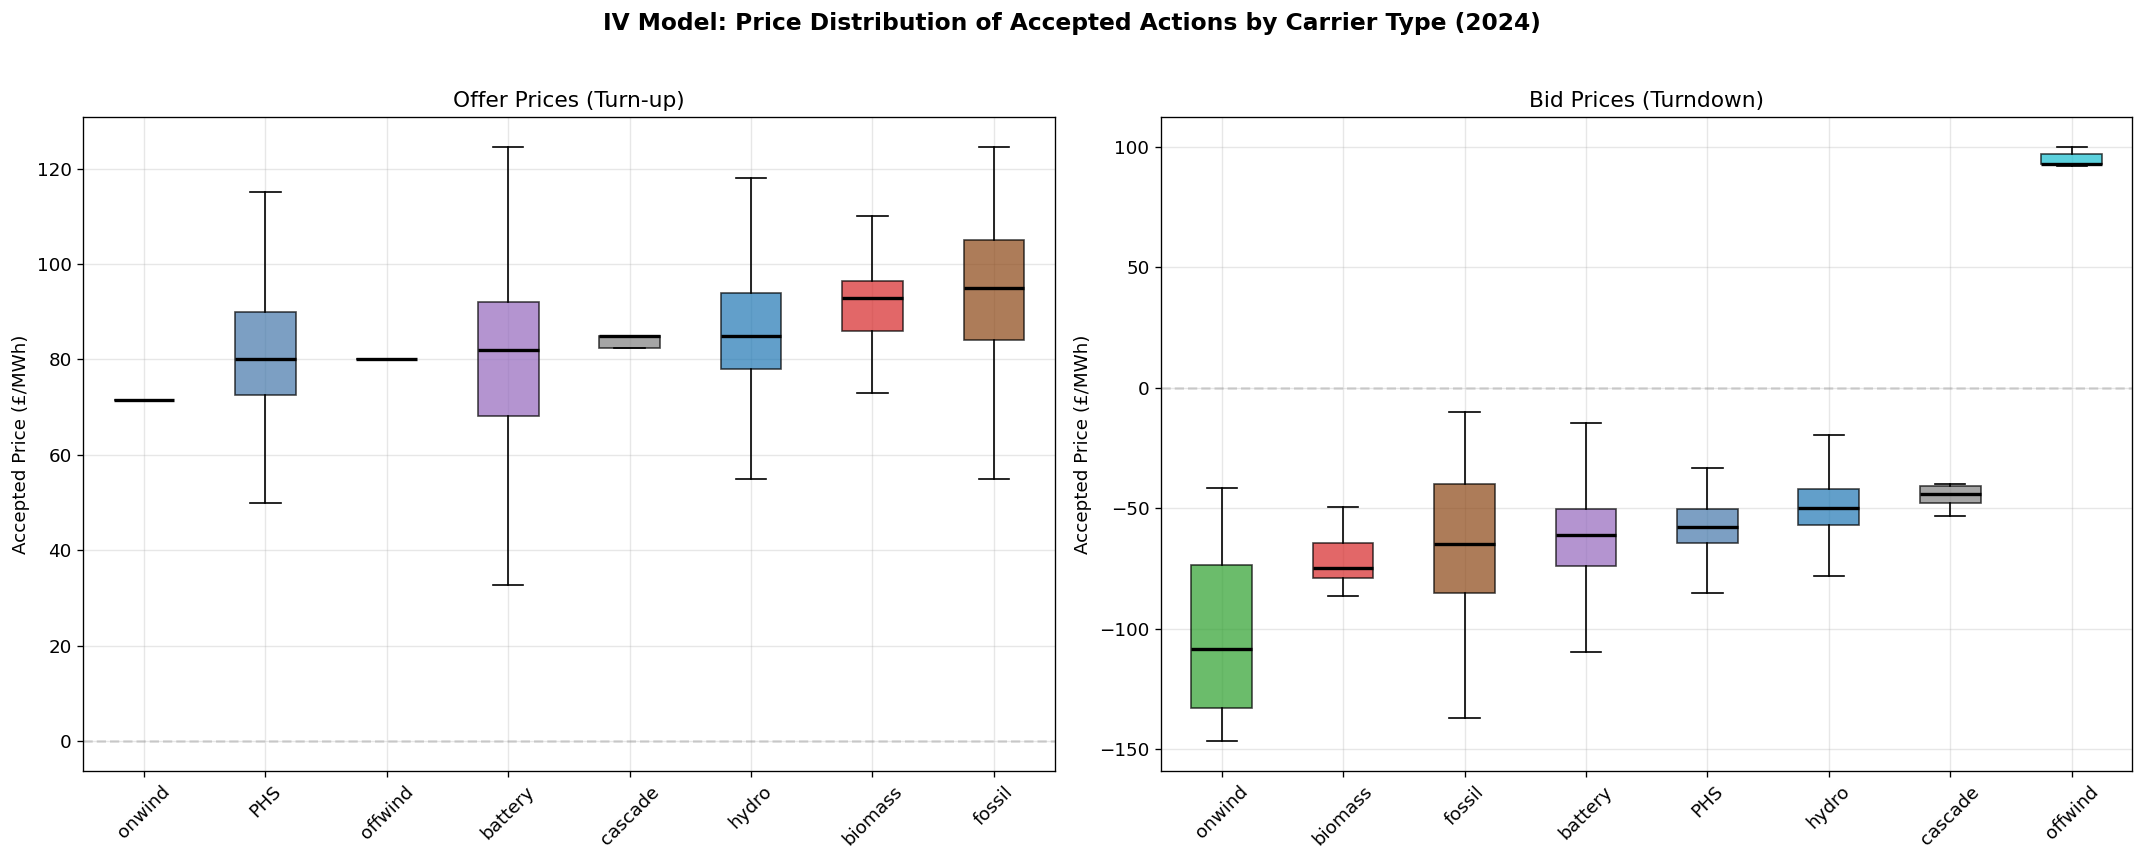


Median accepted price by carrier and direction:
                          median    mean  count
carrier_type action_type                       
PHS          bid          -57.80  -56.72    768
             offer         80.00   82.17   1488
battery      bid          -61.00  -61.01  11563
             offer         82.03   80.36  64056
biomass      bid          -74.70  -72.68    120
             offer         92.99   93.52   3074
cascade      bid          -44.28  -40.92    220
             offer         85.00   82.55    108
fossil       bid          -65.00  -82.07  25570
             offer         96.00  108.93  27075
hydro        bid          -50.00  -48.22  38295
             offer         85.00   87.63   1873
offwind      bid           92.78   82.86    147
             offer         80.00   81.48     25
onwind       bid         -124.57 -125.76     84
             offer         71.50   73.09   4649


In [57]:
# Filter to carriers with enough data points
carrier_counts = iv_actions['carrier_type'].value_counts()
major_carriers = carrier_counts[carrier_counts > 100].index.tolist()

iv_major = iv_actions[iv_actions['carrier_type'].isin(major_carriers)].copy()

# Clip extreme prices for readability
p_low, p_high = iv_major['price_per_mwh'].quantile(0.01), iv_major['price_per_mwh'].quantile(0.99)
iv_major_clipped = iv_major[(iv_major['price_per_mwh'] >= p_low) & (iv_major['price_per_mwh'] <= p_high)]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, direction, title in [
    (axes[0], 'offer', 'Offer Prices (Turn-up)'),
    (axes[1], 'bid', 'Bid Prices (Turndown)'),
]:
    data = iv_major_clipped[iv_major_clipped['action_type'] == direction]
    if data.empty:
        ax.set_title(f'{title} — No data')
        continue
    
    # Order carriers by median price
    order = data.groupby('carrier_type')['price_per_mwh'].median().sort_values().index.tolist()
    
    box_colors = [CARRIER_COLORS.get(c, '#CCCCCC') for c in order]
    
    bp = ax.boxplot(
        [data[data['carrier_type'] == c]['price_per_mwh'].values for c in order],
        labels=order, patch_artist=True, showfliers=False,
        medianprops=dict(color='black', linewidth=2),
    )
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel('Accepted Price (£/MWh)')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(0, color='grey', ls='--', alpha=0.3)

fig.suptitle('IV Model: Price Distribution of Accepted Actions by Carrier Type (2024)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_price_by_carrier.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print("\nMedian accepted price by carrier and direction:")
price_summary = iv_major.groupby(['carrier_type', 'action_type'])['price_per_mwh'].agg(['median', 'mean', 'count'])
print(price_summary.round(2).to_string())

---
## Plot 3g: IV vs Real — Technology Share Comparison by Zone

Direct comparison: for each zone, what share of balancing volume comes from each carrier? Side-by-side IV vs Real. This is perhaps the most informative single chart — it shows both the geographic and technology dimensions simultaneously, and reveals where the model's selection logic diverges most from the real SO.

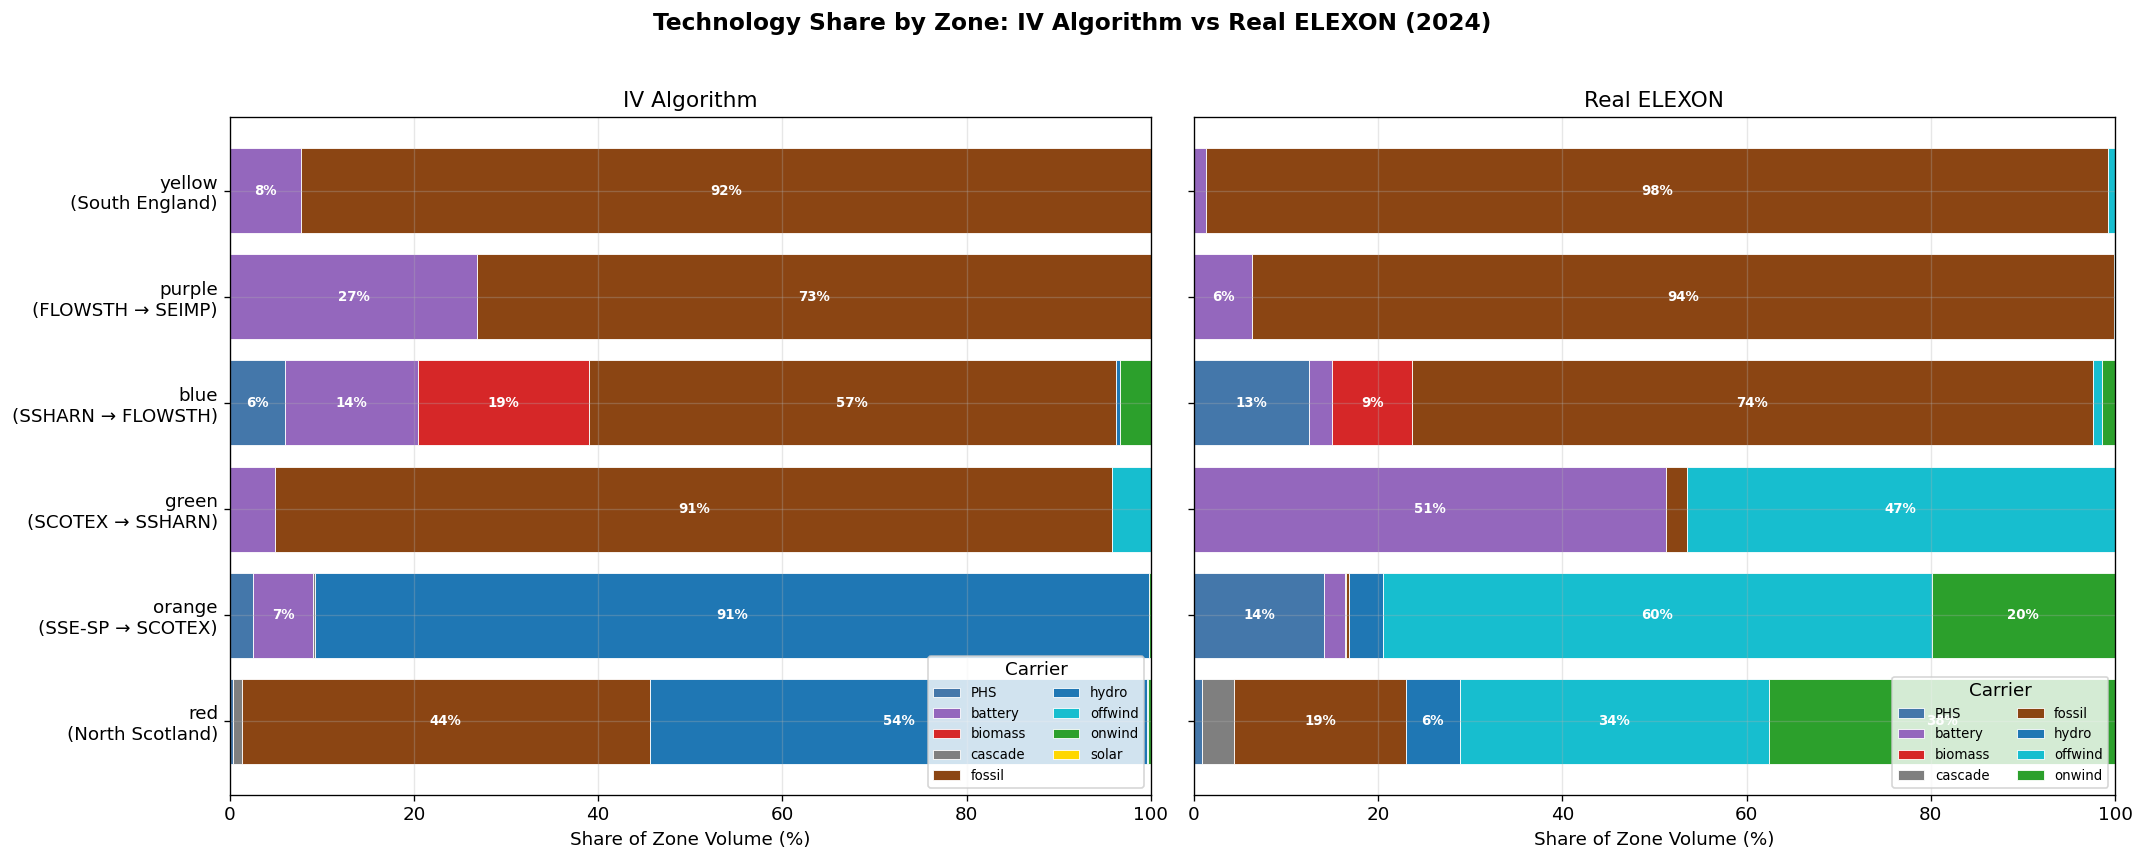

In [58]:
# IV: volume by zone × carrier
iv_zone_carrier = iv_actions.groupby(['zone', 'carrier_type'])['volume_mwh_actual'].sum().unstack(fill_value=0)

# Real: volume by zone × carrier
real_zone_carrier = real_actions.groupby(['zone', 'carrier_type'])['volume_mwh'].sum().unstack(fill_value=0)

# Normalise to % within each zone
iv_zone_pct = iv_zone_carrier.div(iv_zone_carrier.sum(axis=1), axis=0) * 100
real_zone_pct = real_zone_carrier.div(real_zone_carrier.sum(axis=1), axis=0) * 100

# Align zones and carriers
zones_common = [z for z in ZONE_ORDER if z in iv_zone_pct.index or z in real_zone_pct.index]
all_carriers_zc = sorted(set(list(iv_zone_pct.columns) + list(real_zone_pct.columns)))

iv_zone_pct = iv_zone_pct.reindex(index=zones_common, columns=all_carriers_zc, fill_value=0)
real_zone_pct = real_zone_pct.reindex(index=zones_common, columns=all_carriers_zc, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, data, title in [
    (axes[0], iv_zone_pct, 'IV Algorithm'),
    (axes[1], real_zone_pct, 'Real ELEXON'),
]:
    zone_labels = [f"{z}\n({ZONE_NAMES.get(z, z)})" for z in zones_common]
    bottom = np.zeros(len(zones_common))
    
    for carrier in all_carriers_zc:
        vals = data[carrier].values
        if vals.sum() == 0:
            continue
        ax.barh(zone_labels, vals, left=bottom, label=carrier,
                color=CARRIER_COLORS.get(carrier, '#CCCCCC'), edgecolor='white', linewidth=0.5)
        
        # Label segments > 5%
        for i, v in enumerate(vals):
            if v > 5:
                ax.text(bottom[i] + v/2, i, f'{v:.0f}%',
                        ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        bottom += vals
    
    ax.set_xlabel('Share of Zone Volume (%)')
    ax.set_title(title)
    ax.set_xlim(0, 100)
    ax.legend(title='Carrier', loc='lower right', fontsize=8, ncol=2)

fig.suptitle('Technology Share by Zone: IV Algorithm vs Real ELEXON (2024)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_zone_tech_share_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Plot 3h: Balancing Cost Contribution by Carrier Type — IV vs Real

Which technologies **drive balancing costs** and which ones **generate revenue** for the System Operator?

From the SO's perspective:
- **Offers (turn-up)**: SO pays generators to increase output → **cost** (positive £)
- **Bids (turndown)**: SO receives payment from generators reducing output → **revenue** (negative £), or in some cases SO pays for bids too (positive £)

The **net cost** per carrier reveals whether a technology is primarily a cost driver or a revenue source for the SO. Comparing IV vs Real shows whether the algorithm's technology selection leads to higher or lower costs per carrier.

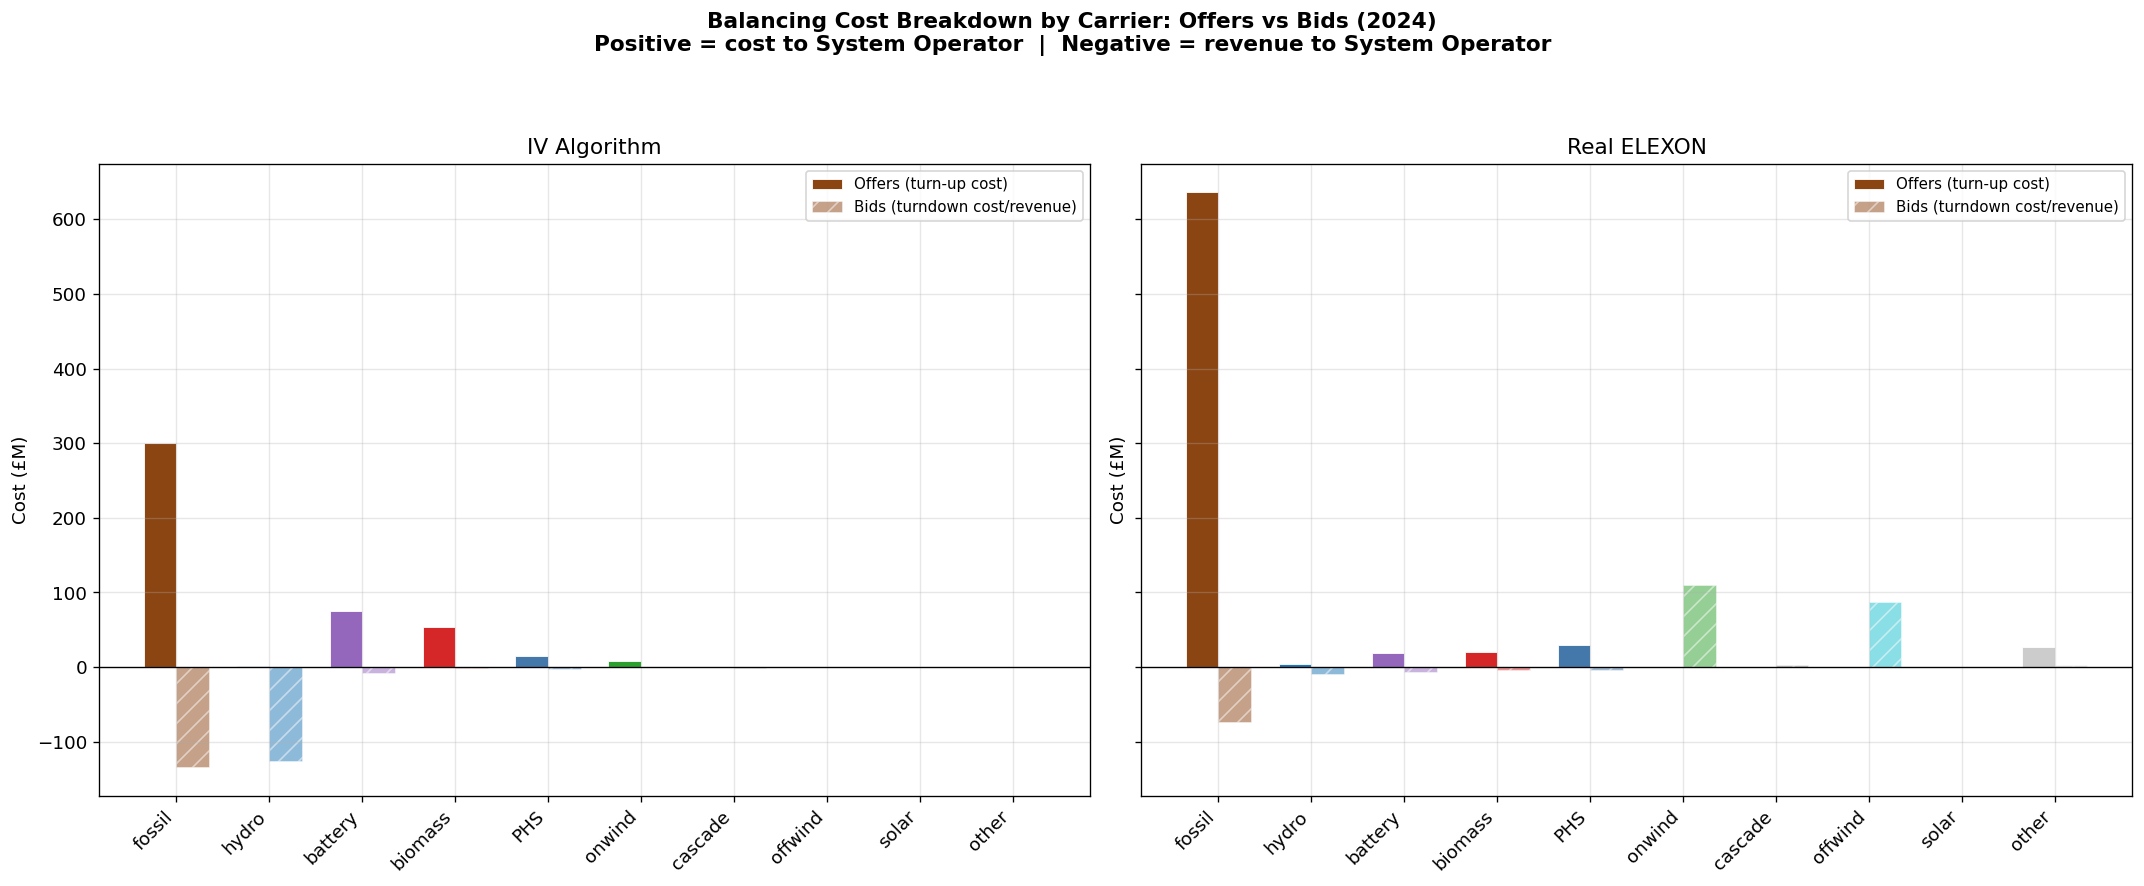

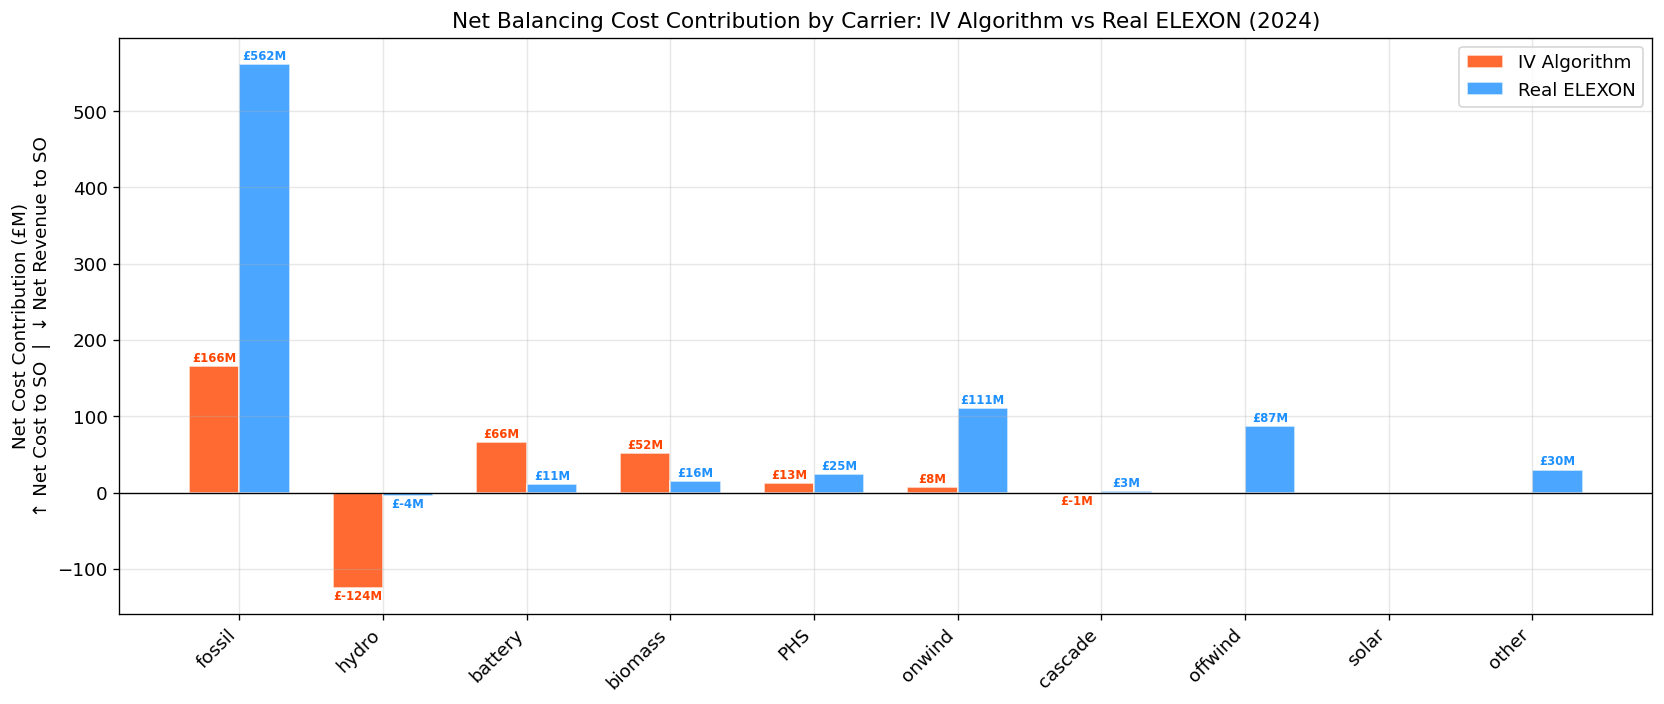


=== Cost Contribution by Carrier (£M) ===
Positive = cost to System Operator | Negative = revenue to System Operator

              IV Offers (£M)  IV Bids (£M)  IV Net (£M)  Real Offers (£M)  Real Bids (£M)  Real Net (£M)
carrier_type                                                                                            
fossil                 299.7        -134.0        165.8             636.0           -74.0          562.0
hydro                    1.7        -126.1       -124.5               4.3            -8.7           -4.4
battery                 74.6          -8.3         66.3              18.4            -7.0           11.3
biomass                 53.1          -0.8         52.3              19.9            -4.2           15.7
PHS                     14.9          -2.4         12.5              29.0            -4.2           24.8
onwind                   8.1          -0.5          7.6               0.3           110.5          110.8
cascade                  0.4          -1.

In [59]:
# ==== Cost Contribution by Carrier Type: IV vs Real ====
# From SO perspective: positive cost_gbp = SO pays out (cost), negative = SO receives (revenue)

# ---- Aggregate cost in £M ----
iv_offer_cost = iv_actions[iv_actions['action_type'] == 'offer'].groupby('carrier_type')['cost_gbp'].sum() / 1e6
iv_bid_cost = iv_actions[iv_actions['action_type'] == 'bid'].groupby('carrier_type')['cost_gbp'].sum() / 1e6
iv_net_cost = iv_actions.groupby('carrier_type')['cost_gbp'].sum() / 1e6

real_offer_cost = real_actions[real_actions['action_type'] == 'offer'].groupby('carrier_type')['cost_gbp'].sum() / 1e6
real_bid_cost = real_actions[real_actions['action_type'] == 'bid'].groupby('carrier_type')['cost_gbp'].sum() / 1e6
real_net_cost = real_actions.groupby('carrier_type')['cost_gbp'].sum() / 1e6

# Align carriers (union of IV and Real)
all_carriers_cost = sorted(set(list(iv_net_cost.index) + list(real_net_cost.index)))
iv_offer_cost = iv_offer_cost.reindex(all_carriers_cost, fill_value=0)
iv_bid_cost = iv_bid_cost.reindex(all_carriers_cost, fill_value=0)
iv_net_cost = iv_net_cost.reindex(all_carriers_cost, fill_value=0)
real_offer_cost = real_offer_cost.reindex(all_carriers_cost, fill_value=0)
real_bid_cost = real_bid_cost.reindex(all_carriers_cost, fill_value=0)
real_net_cost = real_net_cost.reindex(all_carriers_cost, fill_value=0)

# Sort by absolute IV net cost (largest cost driver first)
sort_order = iv_net_cost.abs().sort_values(ascending=False).index.tolist()

# ===== FIGURE 1: Offer & Bid Cost Breakdown by Carrier =====
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, offer_vals, bid_vals, title in [
    (axes[0], iv_offer_cost.reindex(sort_order), iv_bid_cost.reindex(sort_order), 'IV Algorithm'),
    (axes[1], real_offer_cost.reindex(sort_order), real_bid_cost.reindex(sort_order), 'Real ELEXON'),
]:
    x = np.arange(len(sort_order))
    colors = [CARRIER_COLORS.get(c, '#CCCCCC') for c in sort_order]
    width = 0.35

    # Offer costs (typically positive = cost to SO)
    ax.bar(x - width/2, offer_vals.values, width, color=colors,
           edgecolor='white', linewidth=0.5, label='Offers (turn-up cost)')
    # Bid costs (can be positive or negative depending on bid prices)
    ax.bar(x + width/2, bid_vals.values, width, color=colors, alpha=0.5,
           edgecolor='white', linewidth=0.5, hatch='//', label='Bids (turndown cost/revenue)')

    ax.set_xticks(x)
    ax.set_xticklabels(sort_order, rotation=45, ha='right')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_ylabel('Cost (£M)')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9)

fig.suptitle('Balancing Cost Breakdown by Carrier: Offers vs Bids (2024)\n'
             'Positive = cost to System Operator  |  Negative = revenue to System Operator',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_cost_breakdown_by_carrier.png', dpi=150, bbox_inches='tight')
plt.show()

# ===== FIGURE 2: Net Cost Comparison — IV vs Real =====
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(sort_order))
width = 0.35

iv_vals = iv_net_cost.reindex(sort_order).values
real_vals = real_net_cost.reindex(sort_order).values

bar_iv = ax.bar(x - width/2, iv_vals, width, label='IV Algorithm',
                color='orangered', alpha=0.8, edgecolor='white')
bar_real = ax.bar(x + width/2, real_vals, width, label='Real ELEXON',
                  color='dodgerblue', alpha=0.8, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(sort_order, rotation=45, ha='right')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Net Cost Contribution (£M)\n↑ Net Cost to SO  |  ↓ Net Revenue to SO')
ax.set_title('Net Balancing Cost Contribution by Carrier: IV Algorithm vs Real ELEXON (2024)')
ax.legend(fontsize=11)

# Value labels on bars
for i in range(len(sort_order)):
    for val, x_off, col in [(iv_vals[i], -width/2, 'orangered'),
                             (real_vals[i], width/2, 'dodgerblue')]:
        if abs(val) > 0.5:
            ax.text(i + x_off, val + (2.0 if val >= 0 else -2.0),
                    f'£{val:.0f}M',
                    ha='center', va='bottom' if val >= 0 else 'top',
                    fontsize=7, color=col, fontweight='bold')

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_net_cost_by_carrier.png', dpi=150, bbox_inches='tight')
plt.show()

# ===== Summary Table =====
cost_table = pd.DataFrame({
    'IV Offers (£M)': iv_offer_cost.reindex(sort_order),
    'IV Bids (£M)': iv_bid_cost.reindex(sort_order),
    'IV Net (£M)': iv_net_cost.reindex(sort_order),
    'Real Offers (£M)': real_offer_cost.reindex(sort_order),
    'Real Bids (£M)': real_bid_cost.reindex(sort_order),
    'Real Net (£M)': real_net_cost.reindex(sort_order),
}).round(1)

print("\n=== Cost Contribution by Carrier (£M) ===")
print("Positive = cost to System Operator | Negative = revenue to System Operator\n")
print(cost_table.to_string())

iv_total = iv_net_cost.sum()
real_total = real_net_cost.sum()
print(f"\nTotal IV net cost:   £{iv_total:.1f}M (Offers: £{iv_offer_cost.sum():.1f}M, Bids: £{iv_bid_cost.sum():.1f}M)")
print(f"Total Real net cost: £{real_total:.1f}M (Offers: £{real_offer_cost.sum():.1f}M, Bids: £{real_bid_cost.sum():.1f}M)")
print(f"Difference (IV - Real): £{iv_total - real_total:.1f}M")

---
## Summary Statistics

In [60]:
print("=" * 80)
print("TECHNOLOGY MIX SUMMARY — IV ALGORITHM vs REAL ELEXON (2024)")
print("=" * 80)

print("\n--- IV Model —--")
iv_summary = iv_actions.groupby('carrier_type').agg(
    vol_gwh=('volume_mwh_actual', lambda x: x.sum()/1e3),
    cost_mGBP=('cost_gbp', lambda x: x.sum()/1e6),
    n_units=('unit_id', 'nunique'),
    n_days=('date', 'nunique'),
    median_price=('price_per_mwh', 'median'),
).sort_values('vol_gwh', ascending=False)
iv_summary['share_pct'] = iv_summary['vol_gwh'] / iv_summary['vol_gwh'].sum() * 100
iv_summary['cost_per_mwh'] = iv_summary['cost_mGBP'] * 1e3 / iv_summary['vol_gwh']  # £/MWh
print(iv_summary.round(2).to_string())

print("\n--- Real ELEXON ---")
real_summary = real_actions.groupby('carrier_type').agg(
    vol_gwh=('volume_mwh', lambda x: x.sum()/1e3),
    cost_mGBP=('cost_gbp', lambda x: x.sum()/1e6),
    n_bmus=('bmu', 'nunique'),
    n_days=('date', 'nunique'),
).sort_values('vol_gwh', ascending=False)
real_summary['share_pct'] = real_summary['vol_gwh'] / real_summary['vol_gwh'].sum() * 100
real_summary['cost_per_mwh'] = real_summary['cost_mGBP'] * 1e3 / real_summary['vol_gwh']  # £/MWh
print(real_summary.round(2).to_string())

print("\n--- Key Differences ---")
# Merge on carrier
comp = iv_summary[['share_pct']].rename(columns={'share_pct': 'IV share %'})
comp = comp.join(real_summary[['share_pct']].rename(columns={'share_pct': 'Real share %'}), how='outer').fillna(0)
comp['Difference (pp)'] = comp['IV share %'] - comp['Real share %']
comp = comp.sort_values('Difference (pp)', key=abs, ascending=False)
print(comp.round(1).to_string())

print("\n--- Interpretation ---")
most_overrepped = comp['Difference (pp)'].idxmax()
most_underrepped = comp['Difference (pp)'].idxmin()
print(f"Most over-represented in IV model:  {most_overrepped} ({comp.loc[most_overrepped, 'Difference (pp)']:+.1f} pp)")
print(f"Most under-represented in IV model: {most_underrepped} ({comp.loc[most_underrepped, 'Difference (pp)']:+.1f} pp)")

TECHNOLOGY MIX SUMMARY — IV ALGORITHM vs REAL ELEXON (2024)

--- IV Model —--
              vol_gwh  cost_mGBP  n_units  n_days  median_price  share_pct  cost_per_mwh
carrier_type                                                                            
fossil        4935.78     165.78       81     353         68.95      51.27         33.59
hydro         2675.00    -124.46       16     343        -50.00      27.78        -46.53
battery       1061.78      66.27       65     324         77.68      11.03         62.41
biomass        578.11      52.27        5     168         92.71       6.00         90.42
PHS            228.82      12.52       13     145         72.00       2.38         54.73
onwind         115.32       7.60       11     201         71.50       1.20         65.93
cascade         28.89      -0.71        5      37        -41.42       0.30        -24.61
offwind          3.88       0.26        8      28         92.78       0.04         66.13
solar            0.02       0.00